# Morph2REP Ultradian Cyclicity Report (CLIPPED z)
## Per-Mouse GMM + Shuffle Permutation + Baseline-Anchored Z-Scoring + Symmetric Winsorization

### Narrative Structure
1. **Act 1** -- What does the raw data look like?
2. **Act 2** -- What does state classification produce?
3. **Act 3** -- Does any individual mouse show cyclicity?
4. **Act 4** -- What about at the group level?
5. **Act 5** -- Is the signal event-driven?
6. **Act 6** -- Is there a dose-response?
7. **Comprehensive Summary**

**IMPORTANT (per your instructions):**
- GMM is fit on **all QC-kept days** (not baseline-only).
- The only methodological change vs your prior notebook is **clipping / winsorization** of z-scored features (default ±5).


In [1]:
# =============================================================================
# Section 0: Imports and Configuration
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import duckdb

from datetime import datetime
from scipy.signal import cwt, morlet2
from scipy.stats import mannwhitneyu, norm
from sklearn.mixture import GaussianMixture

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42

# --- Distance/bouts settings ---
MINUTES_PER_DAY = 1440
S3_BASE = "s3://jax-envision-public-data/study_1001/2025v3.3/tabular"

# Locomotion state in animal_bouts
LOCO_STATE_NAME = "animal_bouts.locomotion"

# Coverage/QC
THR_MINUTES = 60
THR_RATIO   = 0.30
MIN_QC_DAYS = 8

# Wavelet settings
U_BAND_HOURS = (1, 3)
C_BAND_HOURS = (23, 25)
PERIODS_MINUTES = np.logspace(np.log10(60), np.log10(39 * 60), 50)

# Cyclicity test settings
LAG = 4
N_SIMS_IND = 5000
N_SIMS_GRP = 2000

# NEW: symmetric winsorization (clipping) on z-scored columns
Z_CLIP = 5.0
Q_CLIP = 0.995      # per-mouse |z| quantile computed on baseline days (adaptive clipping)
Q_CLIP_FALLBACK = Z_CLIP  # fallback symmetric cap if too few baseline points

GROUP_COLORS = {"vehicle": "#4878CF", "dose5": "#E8833A", "dose25": "#D65F5F"}
REP_COLORS = {"Rep1": "#4878CF", "Rep2": "#E8833A"}

print("Imports ready.")


Imports ready.


In [2]:
# =============================================================================
# Section 1: Study Configuration
# =============================================================================
COV_COLS = ["animal_id", "start_time", "end_time"]
LOCO_COLS = ["animal_id", "start_time", "end_time", "state_name"]

REPLICATE_META = {
    "Rep1": {
        "analysis_start": "2025-01-07",
        "analysis_end": "2025-01-22",
        "n_days": 16,
        "valid_days": (2, 16),
        "dose_1": datetime(2025, 1, 14, 6, 0),
        "dose_2": datetime(2025, 1, 17, 17, 0),
        "cage_change": datetime(2025, 1, 15, 12, 0),
    },
    "Rep2": {
        "analysis_start": "2025-01-22",
        "analysis_end": "2025-02-04",
        "n_days": 14,
        "valid_days": (2, 14),
        "dose_1": datetime(2025, 1, 28, 17, 0),
        "dose_2": datetime(2025, 1, 31, 6, 0),
        "cage_change": datetime(2025, 1, 29, 12, 0),
    },
}

GROUP_CAGES = {
    "vehicle": {"Rep1": [4918, 4922, 4923], "Rep2": [4928, 4929, 4934]},
    "dose5":   {"Rep1": [4917, 4921, 4925], "Rep2": [4927, 4931, 4932]},
    "dose25":  {"Rep1": [4919, 4920, 4924], "Rep2": [4926, 4930, 4933]},
}

GROUPS = {}
for group_name, rep_map in GROUP_CAGES.items():
    GROUPS[group_name] = {}
    for rep_name, cages in rep_map.items():
        cfg = dict(REPLICATE_META[rep_name])
        cfg["cages"] = list(cages)
        GROUPS[group_name][rep_name] = cfg

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        start_date = pd.to_datetime(cfg["analysis_start"]).date()
        cfg["dose_1_day"] = (cfg["dose_1"].date() - start_date).days + 1
        cfg["dose_2_day"] = (cfg["dose_2"].date() - start_date).days + 1
        cfg["cage_change_day"] = (cfg["cage_change"].date() - start_date).days + 1
        cfg["baseline_days"] = (cfg["valid_days"][0], cfg["dose_1_day"] - 1)
        cfg["event_days"] = {cfg["dose_1_day"], cfg["cage_change_day"], cfg["dose_2_day"]}
        cfg["event_and_next"] = cfg["event_days"] | {d + 1 for d in cfg["event_days"] if (d + 1) <= cfg["n_days"]}

print("Configuration ready.")
for g in GROUPS:
    for rep in ["Rep1", "Rep2"]:
        cfg = GROUPS[g][rep]
        print(f"  {g:7s} {rep} | events=days {sorted(cfg['event_days'])} | baseline=days {cfg['baseline_days'][0]}-{cfg['baseline_days'][1]}")


Configuration ready.
  vehicle Rep1 | events=days [8, 9, 11] | baseline=days 2-7
  vehicle Rep2 | events=days [7, 8, 10] | baseline=days 2-6
  dose5   Rep1 | events=days [8, 9, 11] | baseline=days 2-7
  dose5   Rep2 | events=days [7, 8, 10] | baseline=days 2-6
  dose25  Rep1 | events=days [8, 9, 11] | baseline=days 2-7
  dose25  Rep2 | events=days [7, 8, 10] | baseline=days 2-6


In [3]:
# =============================================================================
# Section 2: Data Loading Helpers
# =============================================================================
def make_duckdb_conn():
    conn = duckdb.connect()
    conn.execute("INSTALL httpfs; LOAD httpfs;")
    conn.execute("SET s3_region='us-east-1';")
    return conn

def load_parquet_s3(conn, cage_id, start_date, end_date, table_name, columns=None, where=None):
    dates = pd.date_range(start_date, end_date, freq="D")
    out = []
    cols_sql = "*" if (not columns) else ", ".join(columns)
    where_sql = "" if (not where) else f" WHERE {where}"
    for d in dates:
        date_str = d.strftime("%Y-%m-%d")
        path = f"{S3_BASE}/cage_id={cage_id}/date={date_str}/{table_name}"
        try:
            df = conn.execute(f"SELECT {cols_sql} FROM read_parquet('{path}'){where_sql}").fetchdf()
            if df.empty:
                continue
            df["cage_id"] = cage_id
            df["date"] = date_str
            out.append(df)
        except Exception:
            continue
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def _ensure_end_time(df):
    df = df.copy()
    for cand in ["end_time", "stop_time"]:
        if cand in df.columns:
            df["end_time"] = pd.to_datetime(df[cand])
            break
    if "end_time" not in df.columns or df["end_time"].isna().all():
        if "duration_seconds" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_seconds"], unit="s")
        else:
            raise ValueError("Need bout end times.")
    df["start_time"] = pd.to_datetime(df["start_time"])
    return df

def compute_minutes_with_any_bout(df_bouts, analysis_start, n_days, anchor_hour=0):
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    df = _ensure_end_time(df_bouts)
    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    start_bin = np.clip(np.floor(s).astype(np.int32), 0, n_minutes)
    end_bin   = np.clip(np.ceil(e).astype(np.int32), 0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    df2 = pd.DataFrame({
        "animal_id": df.loc[valid, "animal_id"].astype(int).to_numpy(),
        "start_bin": start_bin[valid],
        "end_bin": end_bin[valid],
    })

    pieces = []
    for aid, g in df2.groupby("animal_id", sort=False):
        for s0, e0 in g[["start_bin", "end_bin"]].to_numpy():
            d_start = int(s0) // MINUTES_PER_DAY + 1
            d_end   = (int(e0) - 1) // MINUTES_PER_DAY + 1
            for day in range(d_start, d_end + 1):
                day0 = (day - 1) * MINUTES_PER_DAY
                ls = max(int(s0), day0) - day0
                le = min(int(e0), day0 + MINUTES_PER_DAY) - day0
                if le > ls:
                    pieces.append((int(aid), int(day), int(ls), int(le)))

    if not pieces:
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    tmp = pd.DataFrame(pieces, columns=["animal_id", "day", "ls", "le"])
    results = []
    for (aid, day), gg in tmp.groupby(["animal_id", "day"], sort=False):
        intervals = gg[["ls", "le"]].to_numpy()
        intervals = intervals[np.argsort(intervals[:, 0])]
        covered = 0
        cur_s, cur_e = intervals[0]
        for s2, e2 in intervals[1:]:
            if s2 <= cur_e:
                cur_e = max(cur_e, e2)
            else:
                covered += (cur_e - cur_s)
                cur_s, cur_e = s2, e2
        covered += (cur_e - cur_s)
        results.append((int(aid), int(day), int(covered)))

    return pd.DataFrame(results, columns=["animal_id", "day", "minutes_with_any_bout"])

def bouts_to_minute_counts(loco_bouts_df, analysis_start, n_days, anchor_hour=0, binary=True):
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    if loco_bouts_df is None or len(loco_bouts_df) == 0:
        return np.zeros(n_minutes, dtype=float)

    df = _ensure_end_time(loco_bouts_df)
    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return np.zeros(n_minutes, dtype=float)

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    start_bin = np.clip(np.floor(s).astype(np.int32), 0, n_minutes)
    end_bin   = np.clip(np.ceil(e).astype(np.int32), 0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return np.zeros(n_minutes, dtype=np.float32)

    diff = np.zeros(n_minutes + 1, dtype=np.int32)
    np.add.at(diff, start_bin[valid], 1)
    np.add.at(diff, end_bin[valid], -1)
    occ = np.cumsum(diff[:-1])

    return (occ > 0).astype(np.float32) if binary else occ.astype(np.float32)

print("Helpers ready.")


Helpers ready.


In [4]:
# =============================================================================
# Section 3: Wavelet Helpers
# =============================================================================
def compute_wavelet_power(signal_1min, periods_minutes=None, w=5):
    x = pd.Series(signal_1min).interpolate().bfill().ffill().fillna(0).values
    if periods_minutes is None:
        periods_minutes = PERIODS_MINUTES
    periods_minutes = np.asarray(periods_minutes, dtype=float)
    scales = periods_minutes * 1.0 * w / (2 * np.pi)
    coeffs = cwt(x, morlet2, scales, w=w)
    return np.abs(coeffs) ** 2, periods_minutes

def extract_band_power_ts(power, periods_minutes, band_hours, reduce="max"):
    periods_hours = periods_minutes / 60
    mask = (periods_hours >= band_hours[0]) & (periods_hours <= band_hours[1])
    if not np.any(mask):
        return np.zeros(power.shape[1], dtype=float)
    return np.max(power[mask, :], axis=0) if reduce == "max" else np.mean(power[mask, :], axis=0)

def daily_mean_from_minute_ts(minute_ts, n_days):
    out = []
    for d in range(1, n_days + 1):
        s = (d - 1) * MINUTES_PER_DAY
        e = d * MINUTES_PER_DAY
        out.append(np.nanmean(minute_ts[s:e]) if e <= len(minute_ts) else np.nan)
    return out

print("Wavelet helpers ready.")


Wavelet helpers ready.


In [5]:
# =============================================================================
# Section 4: Load Data, QC, Extract Features
# =============================================================================
conn = make_duckdb_conn()

# --- Coverage ---
cov_all = []
print("Loading coverage...")
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        for cage_id in cfg["cages"]:
            df_cov = load_parquet_s3(conn, cage_id, cfg["analysis_start"], cfg["analysis_end"],
                                     "animal_bouts.parquet", columns=COV_COLS)
            if df_cov.empty:
                continue
            cov = compute_minutes_with_any_bout(df_cov, cfg["analysis_start"], cfg["n_days"])
            cov["group"], cov["replicate"], cov["cage_id"] = group, rep, cage_id
            cov = cov[(cov["day"] >= vstart) & (cov["day"] <= vend)]
            cov_all.append(cov)

cov_df = pd.concat(cov_all, ignore_index=True)
cov_df = cov_df[cov_df["animal_id"].notna() & (cov_df["animal_id"].astype(int) != 0)].copy()
med = cov_df.groupby(["group", "replicate", "animal_id"])["minutes_with_any_bout"].transform("median")
cov_df["coverage_ratio"] = (cov_df["minutes_with_any_bout"] / med).replace([np.inf, -np.inf], np.nan).fillna(0)

cov_df["qc_keep"] = (cov_df["minutes_with_any_bout"] >= THR_MINUTES) & (cov_df["coverage_ratio"] >= THR_RATIO)
print(f"Coverage: {len(cov_df)} rows, QC keep rate: {cov_df['qc_keep'].mean():.3f}")

# --- Wavelet features + daily locomotion minutes (for Act 1 plots) ---
rows = []
loco_minutes_rows = []
print("Extracting wavelet features...")

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        n_days = cfg["n_days"]
        start_date = pd.to_datetime(cfg["analysis_start"])
        date_list = [(start_date + pd.Timedelta(days=i)).date() for i in range(n_days)]
        bl_start, bl_end = cfg["baseline_days"]

        for cage_id in cfg["cages"]:
            df_loco = load_parquet_s3(
                conn, cage_id, cfg["analysis_start"], cfg["analysis_end"],
                "animal_bouts.parquet", columns=LOCO_COLS,
                where=f"state_name = '{LOCO_STATE_NAME}'"
            )

            cov_animals = cov_df[
                (cov_df["group"] == group) & (cov_df["replicate"] == rep) & (cov_df["cage_id"] == cage_id)
            ]["animal_id"].dropna().astype(int).unique()

            if len(cov_animals) == 0:
                continue

            for aid in cov_animals:
                a_loco = df_loco[df_loco["animal_id"] == aid].copy() if not df_loco.empty else pd.DataFrame(columns=LOCO_COLS)

                # IMPORTANT: keep this consistent with your notebook
                # binary=False => overlap-count signal (not just on/off)
                x_1min = bouts_to_minute_counts(a_loco, cfg["analysis_start"], n_days, binary=False)

                # Daily locomotion minutes proxy
                for day in range(vstart, vend + 1):
                    s_idx = (day - 1) * MINUTES_PER_DAY
                    e_idx = day * MINUTES_PER_DAY
                    loco_min = float(np.sum(x_1min[s_idx:e_idx])) if e_idx <= len(x_1min) else np.nan
                    loco_minutes_rows.append({
                        "group": group, "replicate": rep, "cage_id": int(cage_id),
                        "animal_id": int(aid), "day": int(day), "loco_minutes": loco_min,
                    })

                power, periods = compute_wavelet_power(x_1min, PERIODS_MINUTES, w=5)
                U_ts = extract_band_power_ts(power, periods, U_BAND_HOURS, reduce="max")
                C_ts = extract_band_power_ts(power, periods, C_BAND_HOURS, reduce="max")

                U_day = daily_mean_from_minute_ts(U_ts, n_days)
                C_day = daily_mean_from_minute_ts(C_ts, n_days)

                for day in range(vstart, vend + 1):
                    u = float(U_day[day - 1])
                    c = float(C_day[day - 1])
                    rows.append({
                        "group": group, "replicate": rep, "cage_id": int(cage_id),
                        "animal_id": int(aid), "day": int(day), "date": str(date_list[day - 1]),
                        "U_1_3h": u, "C_23_25h": c,
                        "log_U_over_C": float(np.log((u + 1e-6) / (c + 1e-6))),
                        "is_event": int(day in cfg["event_days"]),
                        "is_event_or_next": int(day in cfg["event_and_next"]),
                        "is_baseline": int(bl_start <= day <= bl_end),
                    })

feat = pd.DataFrame(rows)
feat = feat[feat["animal_id"].notna() & (feat["animal_id"].astype(int) != 0)].copy()

loco_df = pd.DataFrame(loco_minutes_rows)
loco_df = loco_df[loco_df["animal_id"].notna() & (loco_df["animal_id"].astype(int) != 0)].copy()

merge_cols = ["group", "replicate", "cage_id", "animal_id", "day", "minutes_with_any_bout", "coverage_ratio", "qc_keep"]
feat = feat.merge(cov_df[merge_cols], on=["group", "replicate", "cage_id", "animal_id", "day"], how="left")
feat["qc_keep"] = feat["qc_keep"].fillna(False)

loco_df = loco_df.merge(
    cov_df[["group", "replicate", "cage_id", "animal_id", "day", "qc_keep"]],
    on=["group", "replicate", "cage_id", "animal_id", "day"], how="left"
)

print(f"Feature rows: {len(feat)}, Animals: {feat['animal_id'].nunique()}")


Loading coverage...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Coverage: 753 rows, QC keep rate: 0.992
Extracting wavelet features...
Feature rows: 756, Animals: 54


In [6]:
# =============================================================================
# Section 5: Baseline-Anchored Z-Scoring + PER-MOUSE BASELINE-QUANTILE CLIPPING
# =============================================================================
def baseline_anchored_z(values, baseline_mask, eps=1e-8):
    values = np.asarray(values, dtype=float)
    baseline_mask = np.asarray(baseline_mask, dtype=bool)

    bl_vals = values[baseline_mask & np.isfinite(values)]
    if len(bl_vals) < 3:
        bl_vals = values[np.isfinite(values)]
    if len(bl_vals) < 2:
        return np.full_like(values, np.nan)

    med = np.nanmedian(bl_vals)
    mad = np.nanmedian(np.abs(bl_vals - med))
    return (values - med) / (mad + eps)

def clip_per_mouse_quantile(z_all, baseline_mask, q=0.995, fallback_clip=5.0, min_baseline=4):
    """Compute a per-mouse threshold from baseline days only, then clip all days to ±threshold.
    - z_all: 1D array of z values for all valid days for a mouse
    - baseline_mask: boolean mask aligned to z_all
    """
    z_all = np.asarray(z_all, dtype=float)
    baseline_mask = np.asarray(baseline_mask, dtype=bool)

    z_bl = z_all[baseline_mask & np.isfinite(z_all)]
    if z_bl.size < min_baseline:
        # fallback: use all finite values
        z_bl = z_all[np.isfinite(z_all)]

    if z_bl.size < 2:
        return z_all, np.nan, 0

    thr = float(np.quantile(np.abs(z_bl), q))
    if (not np.isfinite(thr)) or thr <= 0:
        thr = float(fallback_clip)

    z_clip = np.clip(z_all, -thr, thr)
    n_clipped = int(np.sum(np.isfinite(z_all) & (np.abs(z_all) > thr)))
    return z_clip, thr, n_clipped

feat_qc = feat[feat["qc_keep"]].copy()

day_counts = feat_qc.groupby(["group", "replicate", "animal_id"]).size()
keep_mice = day_counts[day_counts >= MIN_QC_DAYS].index
feat_qc = feat_qc.set_index(["group", "replicate", "animal_id"]).loc[keep_mice].reset_index()

# optional diagnostics: store per-mouse thresholds + counts (for z_U_1_3h)
thr_rows = []

for col in ["U_1_3h", "C_23_25h", "log_U_over_C"]:
    z_col = f"z_{col}"
    feat_qc[z_col] = np.nan
    for (g, r, aid), grp in feat_qc.groupby(["group", "replicate", "animal_id"]):
        idx = grp.index
        bl_mask = grp["is_baseline"].values.astype(bool)

        z = baseline_anchored_z(grp[col].values, bl_mask)
        z_clip, thr, n_clipped = clip_per_mouse_quantile(
            z, bl_mask, q=Q_CLIP, fallback_clip=Q_CLIP_FALLBACK
        )
        feat_qc.loc[idx, z_col] = z_clip

        if col == "U_1_3h":
            thr_rows.append({
                "group": g, "replicate": r, "animal_id": int(aid),
                "clip_q": float(Q_CLIP), "thr_abs_z": thr, "n_clipped": int(n_clipped),
                "n_days": int(len(grp)), "n_baseline_days": int(bl_mask.sum())
            })

clip_diag_df = pd.DataFrame(thr_rows)
if len(clip_diag_df) > 0:
    print("Clipping diagnostics (z_U_1_3h):")
    print(clip_diag_df[["thr_abs_z","n_clipped"]].describe().round(3).to_string())

feat_qc = feat_qc.dropna(subset=["z_U_1_3h"]).copy()
print(f"After QC + z-scoring + per-mouse clipping: {len(feat_qc)} rows, {feat_qc['animal_id'].nunique()} mice")


Clipping diagnostics (z_U_1_3h):
       thr_abs_z  n_clipped
count     54.000     54.000
mean       3.660      3.889
std        2.798      2.545
min        1.025      1.000
25%        1.854      1.000
50%        2.607      3.500
75%        4.468      5.750
max       15.394      9.000
After QC + z-scoring + per-mouse clipping: 747 rows, 54 mice


In [7]:
# =============================================================================
# Section 6: Per-Mouse GMM -> p_lowU  (FIT ON ALL QC-KEPT DAYS)
# =============================================================================
gmm_results = []
gmm_objects = {}  # store for Act 2 plots
feat_qc["p_lowU"] = np.nan

for (g, r, aid), grp in feat_qc.groupby(["group", "replicate", "animal_id"]):
    idx = grp.index
    x = grp["z_U_1_3h"].values.reshape(-1, 1)  # NOTE: all QC-kept days
    if len(x) < 6:
        gmm_results.append({"group": g, "replicate": r, "animal_id": aid, "n_days": len(x), "status": "too_few", "sep": np.nan})
        continue
    try:
        gmm = GaussianMixture(n_components=2, covariance_type="full", reg_covar=1e-4, random_state=SEED, n_init=5)
        gmm.fit(x)
        post = gmm.predict_proba(x)
        means = gmm.means_.flatten()
        low_comp = int(np.argmin(means))
        feat_qc.loc[idx, "p_lowU"] = post[:, low_comp]
        sep = abs(means[0] - means[1])
        gmm_results.append({
            "group": g, "replicate": r, "animal_id": aid, "n_days": len(x), "status": "ok",
            "sep": sep, "m0": means[0], "m1": means[1], "w0": gmm.weights_[0], "w1": gmm.weights_[1], "low_comp": low_comp
        })
        gmm_objects[(g, r, aid)] = gmm
    except Exception:
        gmm_results.append({"group": g, "replicate": r, "animal_id": aid, "n_days": len(x), "status": "error", "sep": np.nan})

gmm_df = pd.DataFrame(gmm_results)
feat_qc = feat_qc.dropna(subset=["p_lowU"]).copy()
n_ok = (gmm_df["status"] == "ok").sum()
print(f"Per-mouse GMM: {n_ok}/{len(gmm_df)} succeeded")
print(f"After GMM: {len(feat_qc)} rows, {feat_qc['animal_id'].nunique()} mice")


Per-mouse GMM: 54/54 succeeded
After GMM: 747 rows, 54 mice


In [8]:
# =============================================================================
# Section 7: Cyclicity Test Functions
# =============================================================================
def autocorr_lag(series_by_day, lag=4):
    s = series_by_day.sort_index()
    s_shift = s.shift(-lag)
    mask = s.notna() & s_shift.notna()
    if mask.sum() < 3:
        return np.nan
    x0, x1 = s[mask].values.astype(float), s_shift[mask].values.astype(float)
    if np.nanstd(x0) < 1e-10 or np.nanstd(x1) < 1e-10:
        return np.nan
    return float(np.corrcoef(x0, x1)[0, 1])

def n_valid_pairs(series_by_day, lag=4):
    s = series_by_day.sort_index()
    return int((s.notna() & s.shift(-lag).notna()).sum())

def parametric_p_one_sided(ac, n_pairs):
    if np.isnan(ac) or n_pairs < 4:
        return np.nan
    return float(1.0 - norm.cdf(ac / (1.0 / np.sqrt(n_pairs))))

def shuffle_test_individual(series_by_day, lag=4, n_sims=5000, seed=0):
    rng = np.random.default_rng(seed)
    s = series_by_day.sort_index()
    obs_ac = autocorr_lag(s, lag=lag)
    if np.isnan(obs_ac):
        return np.nan, np.nan, 0, np.array([])
    vals = s.values.copy()
    nan_mask = ~np.isfinite(vals)
    obs_vals = vals[~nan_mask]
    n_pairs_val = n_valid_pairs(s, lag)
    if len(obs_vals) < lag + 3:
        return obs_ac, np.nan, n_pairs_val, np.array([])
    null_acs = np.empty(n_sims)
    for i in range(n_sims):
        shuffled = obs_vals.copy()
        rng.shuffle(shuffled)
        vp = vals.copy()
        vp[~nan_mask] = shuffled
        null_acs[i] = autocorr_lag(pd.Series(vp, index=s.index), lag=lag)
    null_f = null_acs[np.isfinite(null_acs)]
    p = float((np.sum(null_f >= obs_ac) + 1) / (len(null_f) + 1)) if len(null_f) > 0 else np.nan
    return obs_ac, p, n_pairs_val, null_acs

def shuffle_test_group(df, prob_col="p_lowU", lag=4, n_sims=2000, seed=0):
    rng = np.random.default_rng(seed)
    mouse_data = {}
    for aid, grp in df.groupby("animal_id"):
        grp = grp.sort_values("day")
        dmin, dmax = int(grp["day"].min()), int(grp["day"].max())
        s = grp.set_index("day")[prob_col].sort_index()
        s = s[~s.index.duplicated(keep="last")].reindex(pd.Index(range(dmin, dmax + 1)))
        mouse_data[aid] = s

    obs_acs = {aid: autocorr_lag(s, lag) for aid, s in mouse_data.items()}
    obs_mean = float(np.nanmean(list(obs_acs.values())))

    null_means = np.empty(n_sims)
    for i in range(n_sims):
        sim_acs = []
        for aid, s in mouse_data.items():
            vals = s.values.copy()
            nm = ~np.isfinite(vals)
            ov = vals[~nm]
            if len(ov) > 1:
                rng.shuffle(ov)
                vals[~nm] = ov
            sim_acs.append(autocorr_lag(pd.Series(vals, index=s.index), lag))
        null_means[i] = np.nanmean(sim_acs)

    null_f = null_means[np.isfinite(null_means)]
    p = float((np.sum(null_f >= obs_mean) + 1) / (len(null_f) + 1)) if len(null_f) > 0 else np.nan
    return obs_mean, p, null_means, obs_acs

print("Cyclicity functions ready.")


Cyclicity functions ready.


In [9]:
# =============================================================================
# Section 8: Run All Cyclicity Tests
# =============================================================================
# --- Individual ---
print("Running individual tests...")
indiv_results = []
indiv_nulls = {}  # store for plotting

for (g, r, aid), grp in feat_qc.groupby(["group", "replicate", "animal_id"]):
    grp = grp.sort_values("day")
    dmin, dmax = int(grp["day"].min()), int(grp["day"].max())
    full_idx = pd.Index(range(dmin, dmax + 1))
    s_all = grp.set_index("day")["p_lowU"].sort_index()
    s_all = s_all[~s_all.index.duplicated(keep="last")].reindex(full_idx)

    obs_ac, p_shuf, np_all, null_dist = shuffle_test_individual(
        s_all, LAG, N_SIMS_IND, seed=hash((g, r, aid)) % (2**31)
    )
    p_par = parametric_p_one_sided(obs_ac, np_all)

    # Event-day censored
    s_ne = s_all.copy()
    cfg = GROUPS[g][r]
    for ed in cfg["event_days"]:
        if ed in s_ne.index:
            s_ne.loc[ed] = np.nan

    obs_ac_ne, p_shuf_ne, np_ne, _ = shuffle_test_individual(
        s_ne, LAG, N_SIMS_IND, seed=hash((g, r, aid, "ne")) % (2**31)
    )
    p_par_ne = parametric_p_one_sided(obs_ac_ne, np_ne)

    indiv_results.append({
        "group": g, "replicate": r, "animal_id": aid, "n_days": len(grp),
        "autocorr_all": obs_ac, "p_shuffle_all": p_shuf, "p_param_all": p_par, "n_pairs_all": np_all,
        "autocorr_ne": obs_ac_ne, "p_shuffle_ne": p_shuf_ne, "p_param_ne": p_par_ne, "n_pairs_ne": np_ne,
    })
    indiv_nulls[(g, r, aid)] = null_dist

indiv_df = pd.DataFrame(indiv_results)
n_sig = int((indiv_df["p_shuffle_all"] < 0.05).sum())
expected_fp = len(indiv_df) * 0.05
print(f"Individual: {n_sig}/{len(indiv_df)} significant (expected FP: {expected_fp:.1f})")

# --- Group ---
print("Running group tests...")
group_results = []
group_nulls = {}

for (g, r), grp in feat_qc.groupby(["group", "replicate"]):
    obs, p, null, per_mouse = shuffle_test_group(grp, "p_lowU", LAG, N_SIMS_GRP, seed=hash((g, r, "all")) % (2**31))

    grp_ne = grp.copy()
    grp_ne.loc[grp_ne["is_event"] == 1, "p_lowU"] = np.nan
    obs_ne, p_ne, null_ne, pm_ne = shuffle_test_group(grp_ne, "p_lowU", LAG, N_SIMS_GRP, seed=hash((g, r, "ne")) % (2**31))

    grp_nw = grp.copy()
    grp_nw.loc[grp_nw["is_event_or_next"] == 1, "p_lowU"] = np.nan
    obs_nw, p_nw, null_nw, pm_nw = shuffle_test_group(grp_nw, "p_lowU", LAG, N_SIMS_GRP, seed=hash((g, r, "nw")) % (2**31))

    group_results.append({
        "group": g, "replicate": r, "n_mice": grp["animal_id"].nunique(),
        "ac_all": obs, "p_all": p, "ac_ne": obs_ne, "p_ne": p_ne, "ac_nw": obs_nw, "p_nw": p_nw,
        "_per_mouse_acs": per_mouse,
    })
    group_nulls[(g, r)] = {"all": null, "ne": null_ne, "nw": null_nw}

group_df = pd.DataFrame(group_results)
print("Group results:")
print(group_df[["group","replicate","n_mice","ac_all","p_all","ac_ne","p_ne","ac_nw","p_nw"]].round(4).to_string(index=False))

# --- Event confound enrichment ---
confound_results = []
for (g, r), grp in feat_qc.groupby(["group", "replicate"]):
    ev = grp.loc[grp["is_event_or_next"] == 1, "p_lowU"].dropna().values
    ne = grp.loc[grp["is_event_or_next"] == 0, "p_lowU"].dropna().values
    if len(ev) > 0 and len(ne) > 0:
        _, p_mwu = mannwhitneyu(ev, ne, alternative="greater")
        delta = float(np.mean(ev) - np.mean(ne))
    else:
        p_mwu, delta = np.nan, np.nan
    confound_results.append({
        "group": g, "replicate": r,
        "mean_ev": float(np.mean(ev)) if len(ev) > 0 else np.nan,
        "mean_ne": float(np.mean(ne)) if len(ne) > 0 else np.nan,
        "delta": delta, "mwu_p": p_mwu
    })
confound_df = pd.DataFrame(confound_results)


Running individual tests...
Individual: 6/54 significant (expected FP: 2.7)
Running group tests...
Group results:
  group replicate  n_mice  ac_all  p_all   ac_ne   p_ne  ac_nw  p_nw
 dose25      Rep1       9  0.2043 0.0060  0.5658 0.0010    NaN   NaN
 dose25      Rep2       9 -0.1119 0.6507 -0.1698 0.4668    NaN   NaN
  dose5      Rep1       9  0.1873 0.0105  0.3202 0.0165    NaN   NaN
  dose5      Rep2       9  0.2004 0.0110  0.5156 0.0100    NaN   NaN
vehicle      Rep1       9  0.2312 0.0035  0.2707 0.0185    NaN   NaN
vehicle      Rep2       9  0.3485 0.0005  0.2359 0.0765    NaN   NaN


---
# Act 1: What Does the Raw Data Look Like?
Before any modeling, we look at the raw locomotor signal to build intuition about what periodicity might look like, and whether events dominate.


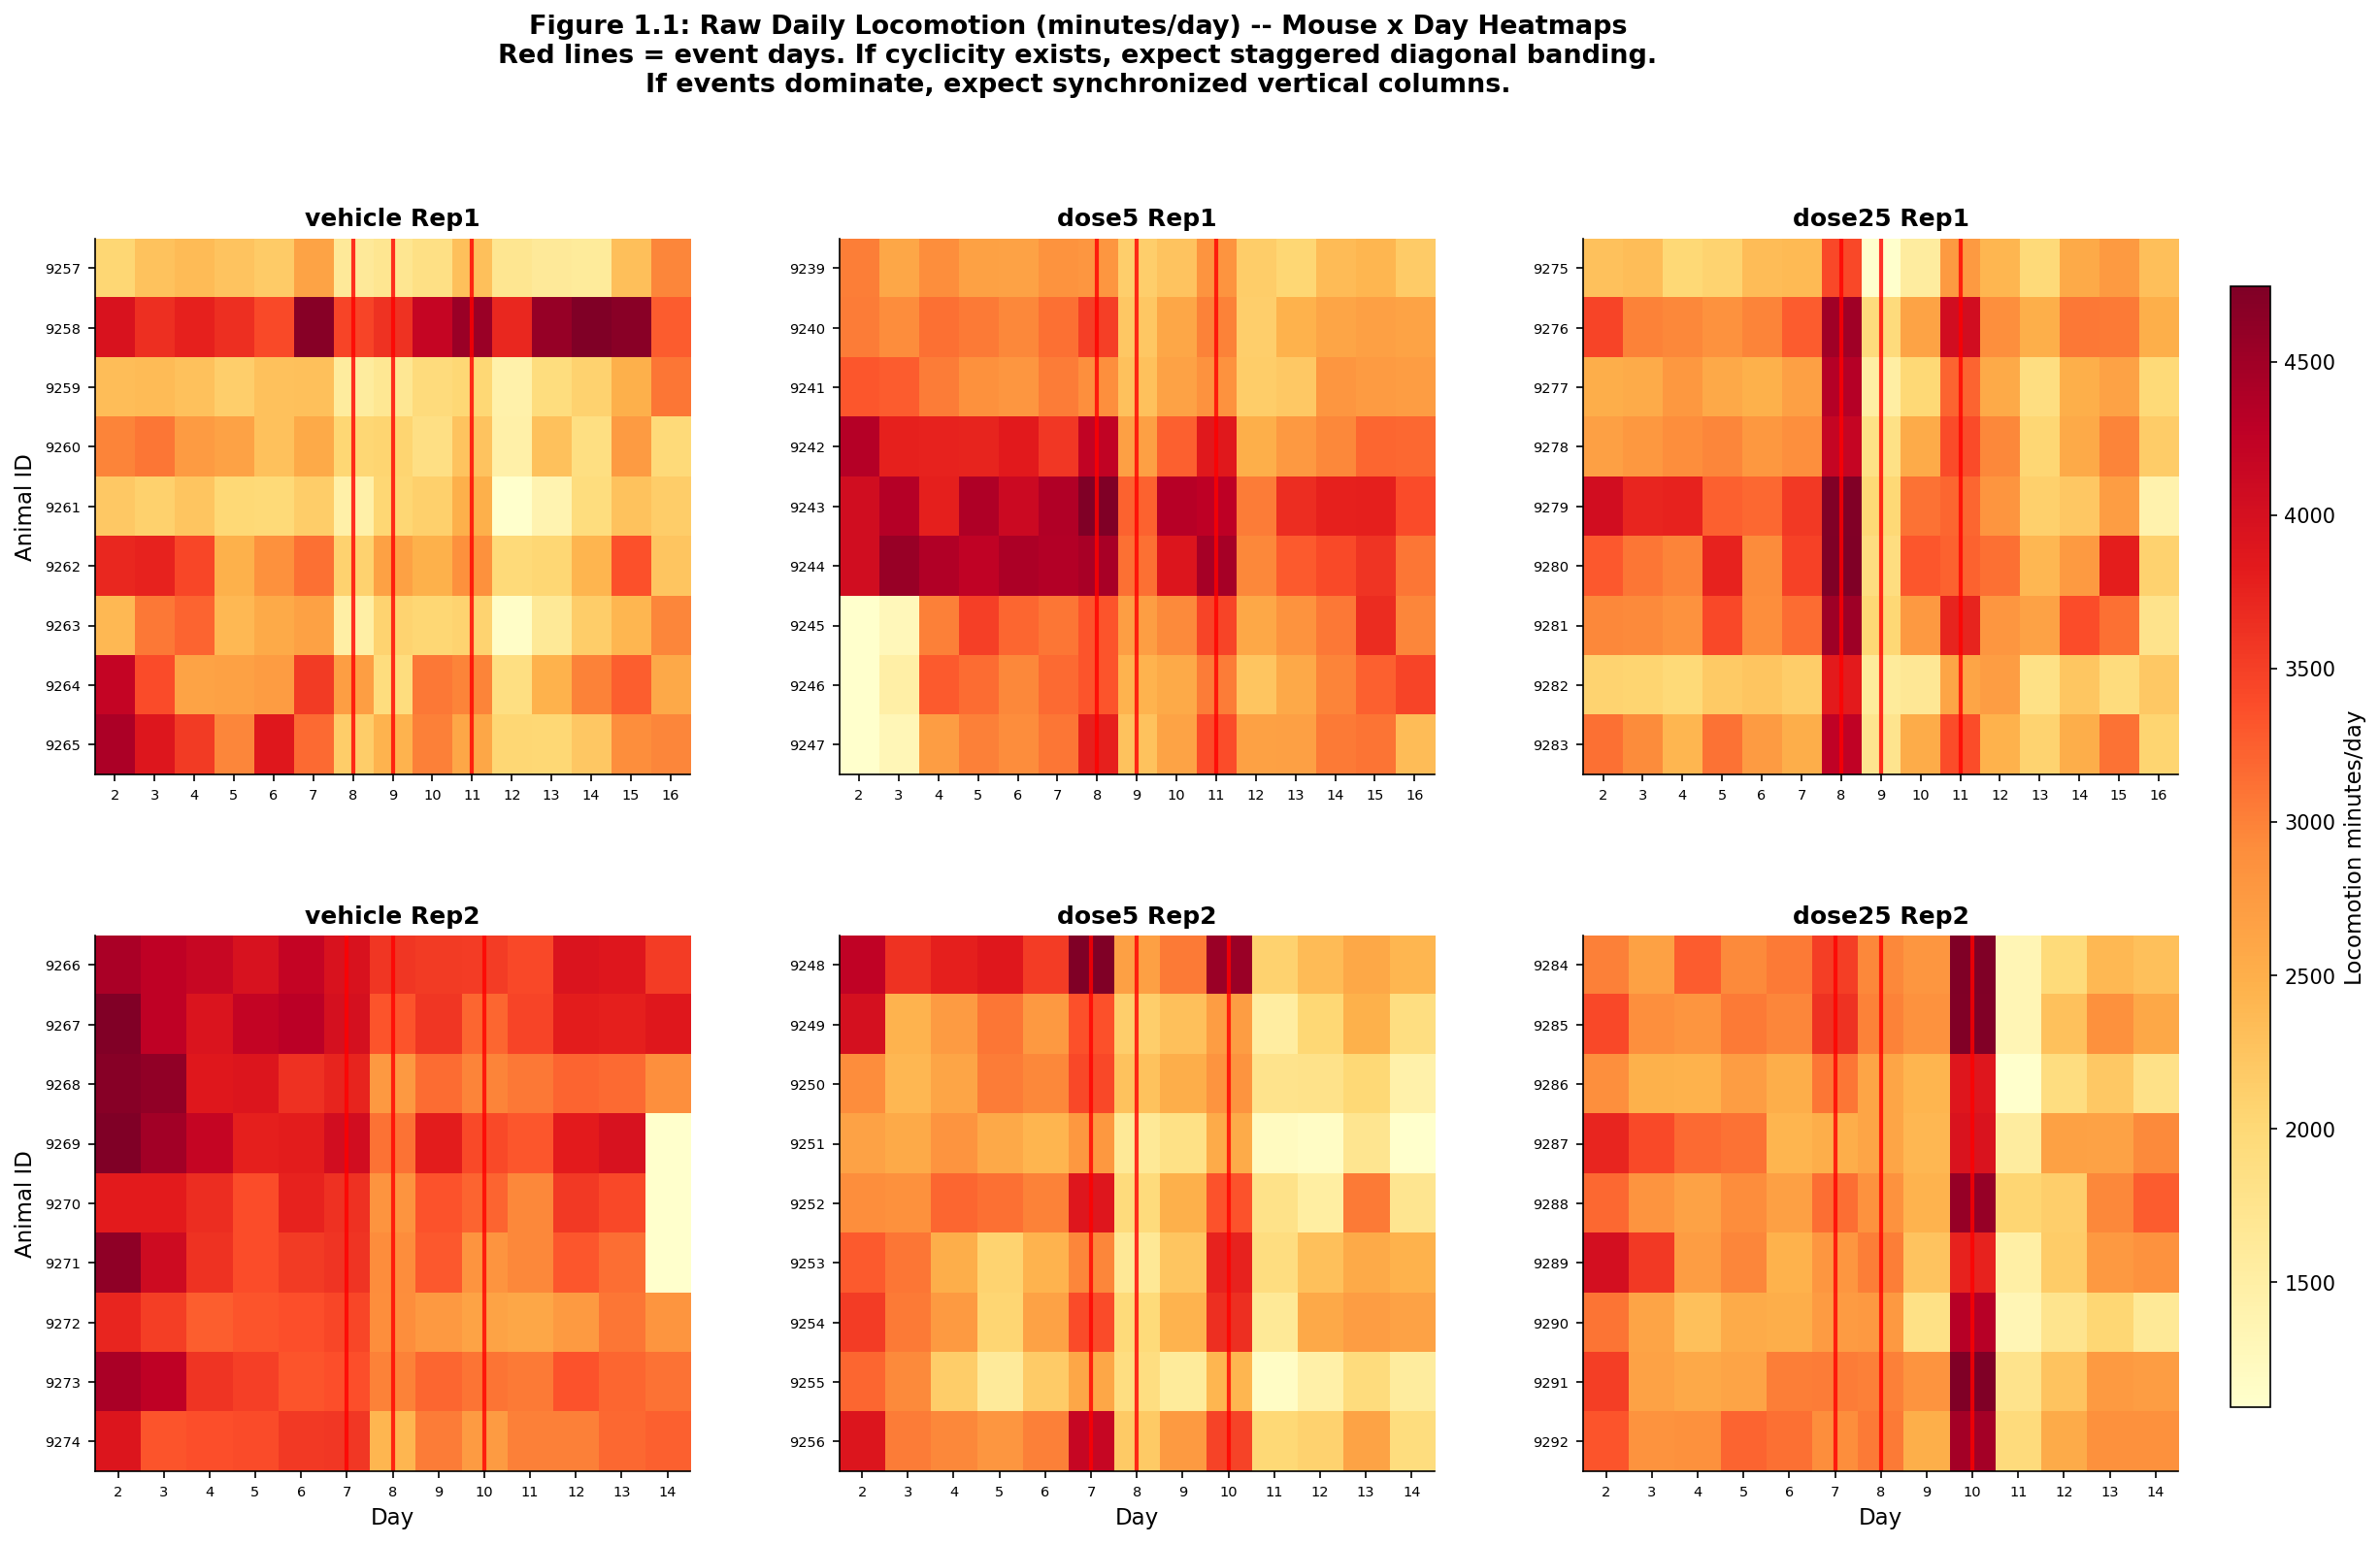

In [10]:
# =============================================================================
# Figure 1.1: Raw Daily Locomotion Heatmaps (Mouse x Day)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Figure 1.1: Raw Daily Locomotion (minutes/day) -- Mouse x Day Heatmaps\n"
             "Red lines = event days. If cyclicity exists, expect staggered diagonal banding.\n"
             "If events dominate, expect synchronized vertical columns.",
             fontsize=13, fontweight="bold", y=1.02)

for i, group in enumerate(["vehicle", "dose5", "dose25"]):
    for j, rep in enumerate(["Rep1", "Rep2"]):
        ax = axes[j, i]
        sub = loco_df[(loco_df["group"] == group) & (loco_df["replicate"] == rep)].copy()
        sub = sub[sub["animal_id"].isin(feat_qc["animal_id"].unique())]
        if len(sub) == 0:
            ax.set_title(f"{group} {rep}")
            continue

        heat = sub.pivot_table(index="animal_id", columns="day", values="loco_minutes", aggfunc="mean").sort_index()
        im = ax.imshow(heat.values, aspect="auto", interpolation="nearest", cmap="YlOrRd")
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels([str(a) for a in heat.index], fontsize=7)
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels([str(d) for d in heat.columns], fontsize=7)

        cfg = GROUPS[group][rep]
        for ed in sorted(cfg["event_days"]):
            if ed in heat.columns:
                col_idx = list(heat.columns).index(ed)
                ax.axvline(col_idx, color="red", linewidth=2, alpha=0.8)

        ax.set_title(f"{group} {rep}", fontweight="bold")
        if j == 1:
            ax.set_xlabel("Day")
        if i == 0:
            ax.set_ylabel("Animal ID")

fig.subplots_adjust(right=0.92, hspace=0.3, wspace=0.25)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Locomotion minutes/day")
plt.show()


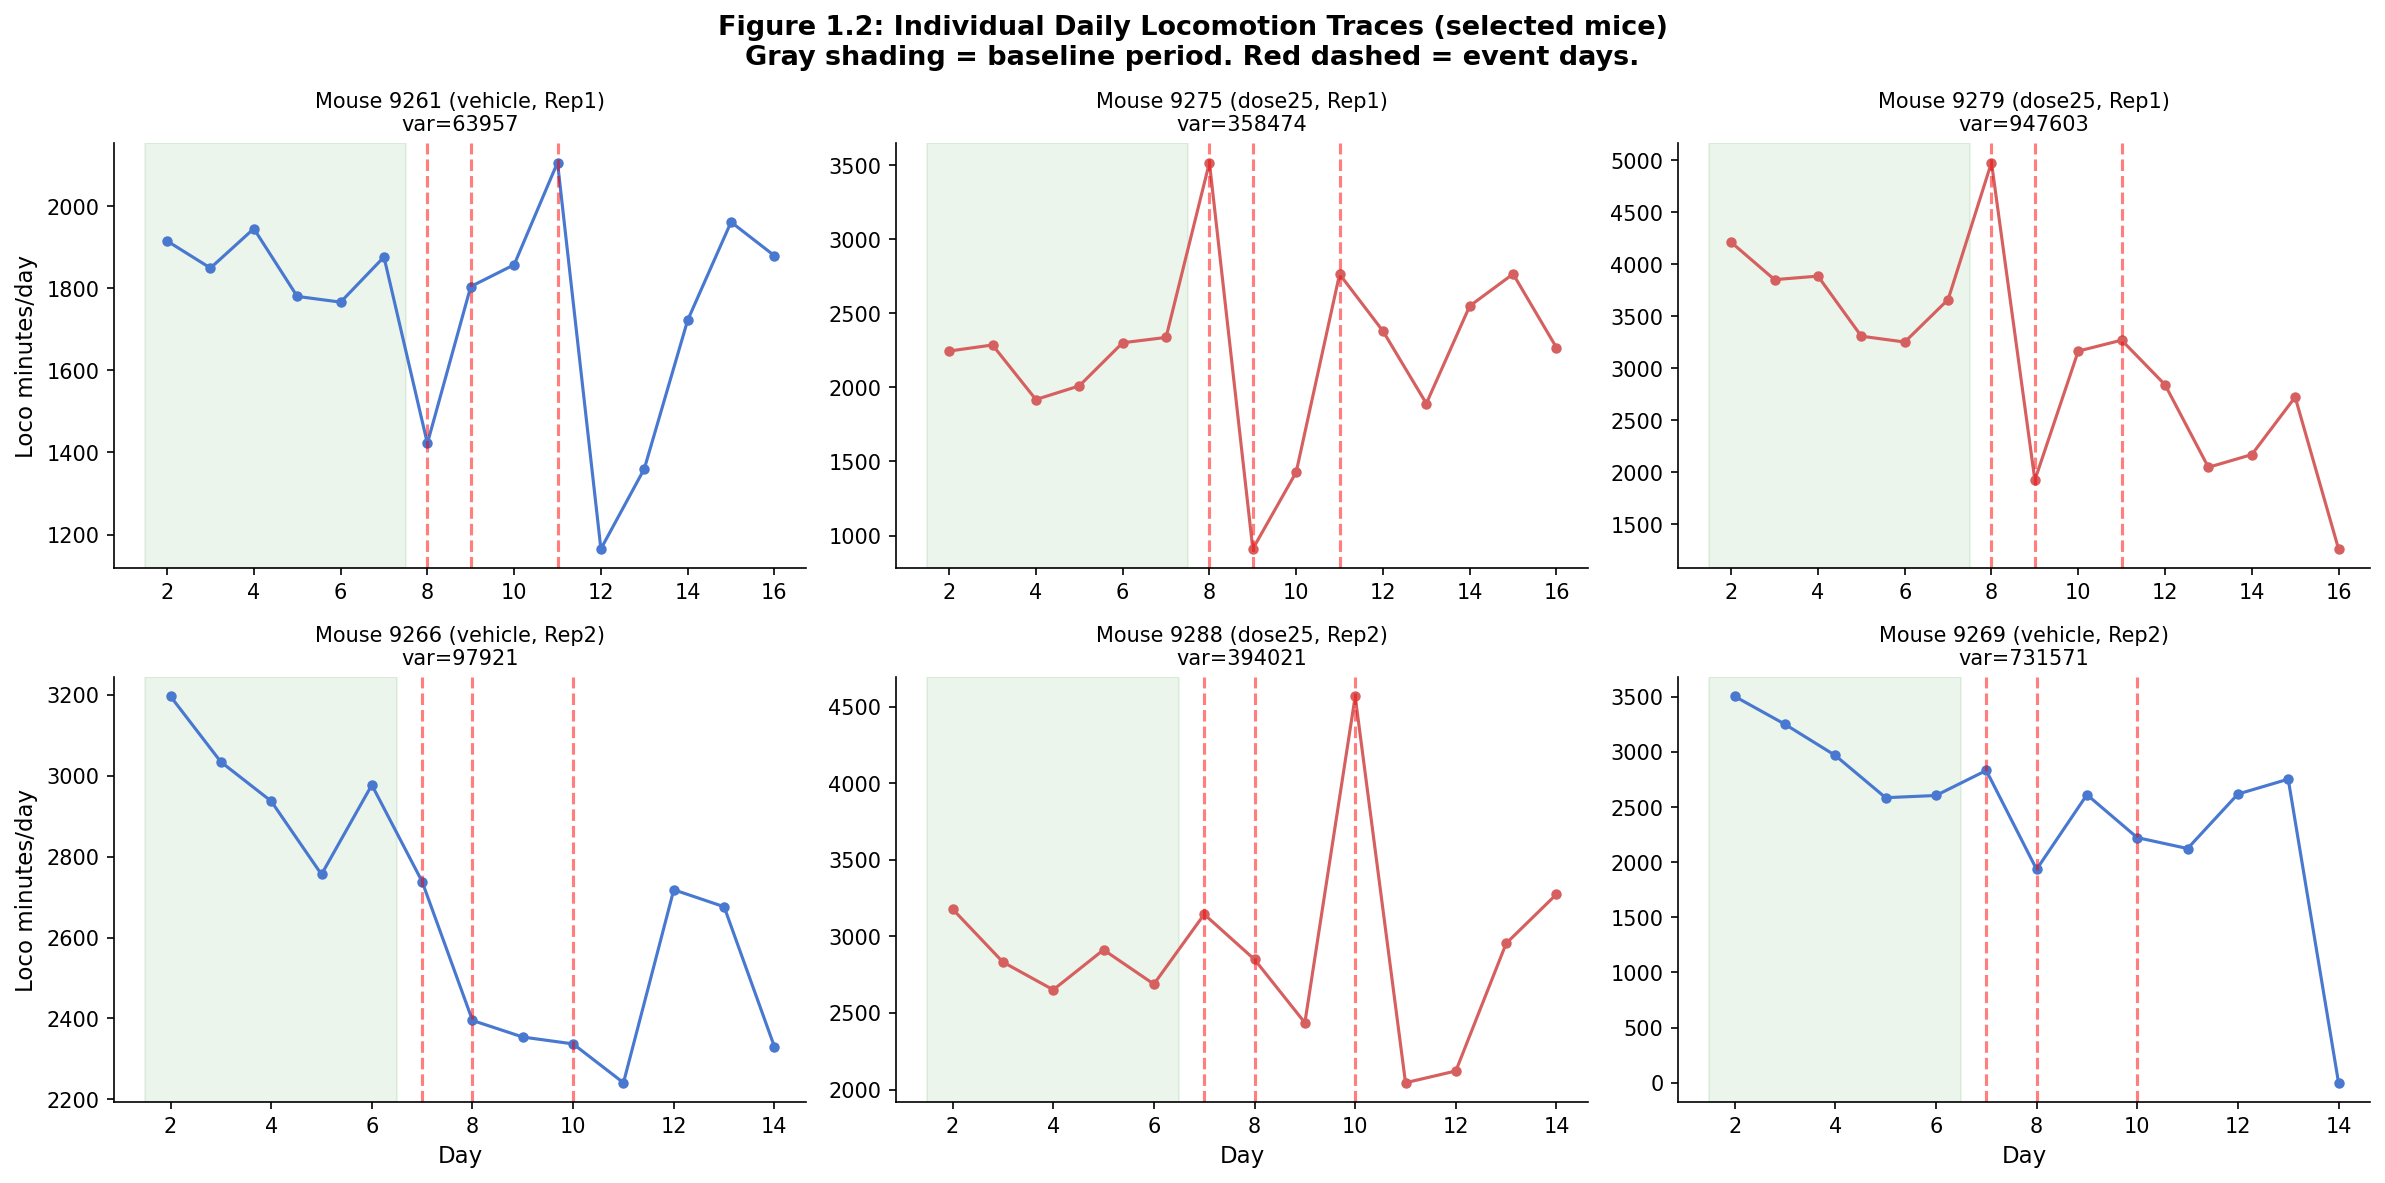

In [11]:
# =============================================================================
# Figure 1.2: Individual Mouse Locomotion Traces (Selected)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Figure 1.2: Individual Daily Locomotion Traces (selected mice)\n"
             "Gray shading = baseline period. Red dashed = event days.",
             fontsize=13, fontweight="bold")

for j, rep in enumerate(["Rep1", "Rep2"]):
    sub = loco_df[(loco_df["replicate"] == rep)].copy()
    sub = sub[sub["animal_id"].isin(feat_qc["animal_id"].unique())]

    var_by_mouse = sub.groupby("animal_id")["loco_minutes"].var().sort_values()
    n = len(var_by_mouse)
    picks = [var_by_mouse.index[0], var_by_mouse.index[n//2], var_by_mouse.index[-1]]

    for k, aid in enumerate(picks):
        ax = axes[j, k]
        m = sub[sub["animal_id"] == aid].sort_values("day")
        grp_name = feat_qc.loc[feat_qc["animal_id"] == aid, "group"].values[0] if aid in feat_qc["animal_id"].values else "?"

        ax.plot(m["day"], m["loco_minutes"], color=GROUP_COLORS.get(grp_name, "gray"),
                marker="o", markersize=4, linewidth=1.5)
        ax.set_title(f"Mouse {aid} ({grp_name}, {rep})\nvar={var_by_mouse[aid]:.0f}", fontsize=10)

        cfg = REPLICATE_META[rep]
        start_date = pd.to_datetime(cfg["analysis_start"]).date()
        bl_end = (cfg["dose_1"].date() - start_date).days
        ax.axvspan(cfg["valid_days"][0] - 0.5, bl_end + 0.5, alpha=0.08, color="green")
        for ev_dt in [cfg["dose_1"], cfg["dose_2"], cfg["cage_change"]]:
            ed = (ev_dt.date() - start_date).days + 1
            ax.axvline(ed, color="red", linestyle="--", alpha=0.5)

        if j == 1:
            ax.set_xlabel("Day")
        if k == 0:
            ax.set_ylabel("Loco minutes/day")

plt.tight_layout()
plt.show()


---
# Act 2: What Does State Classification Produce?
Show how per-mouse GMM transforms z_U into p_lowU.


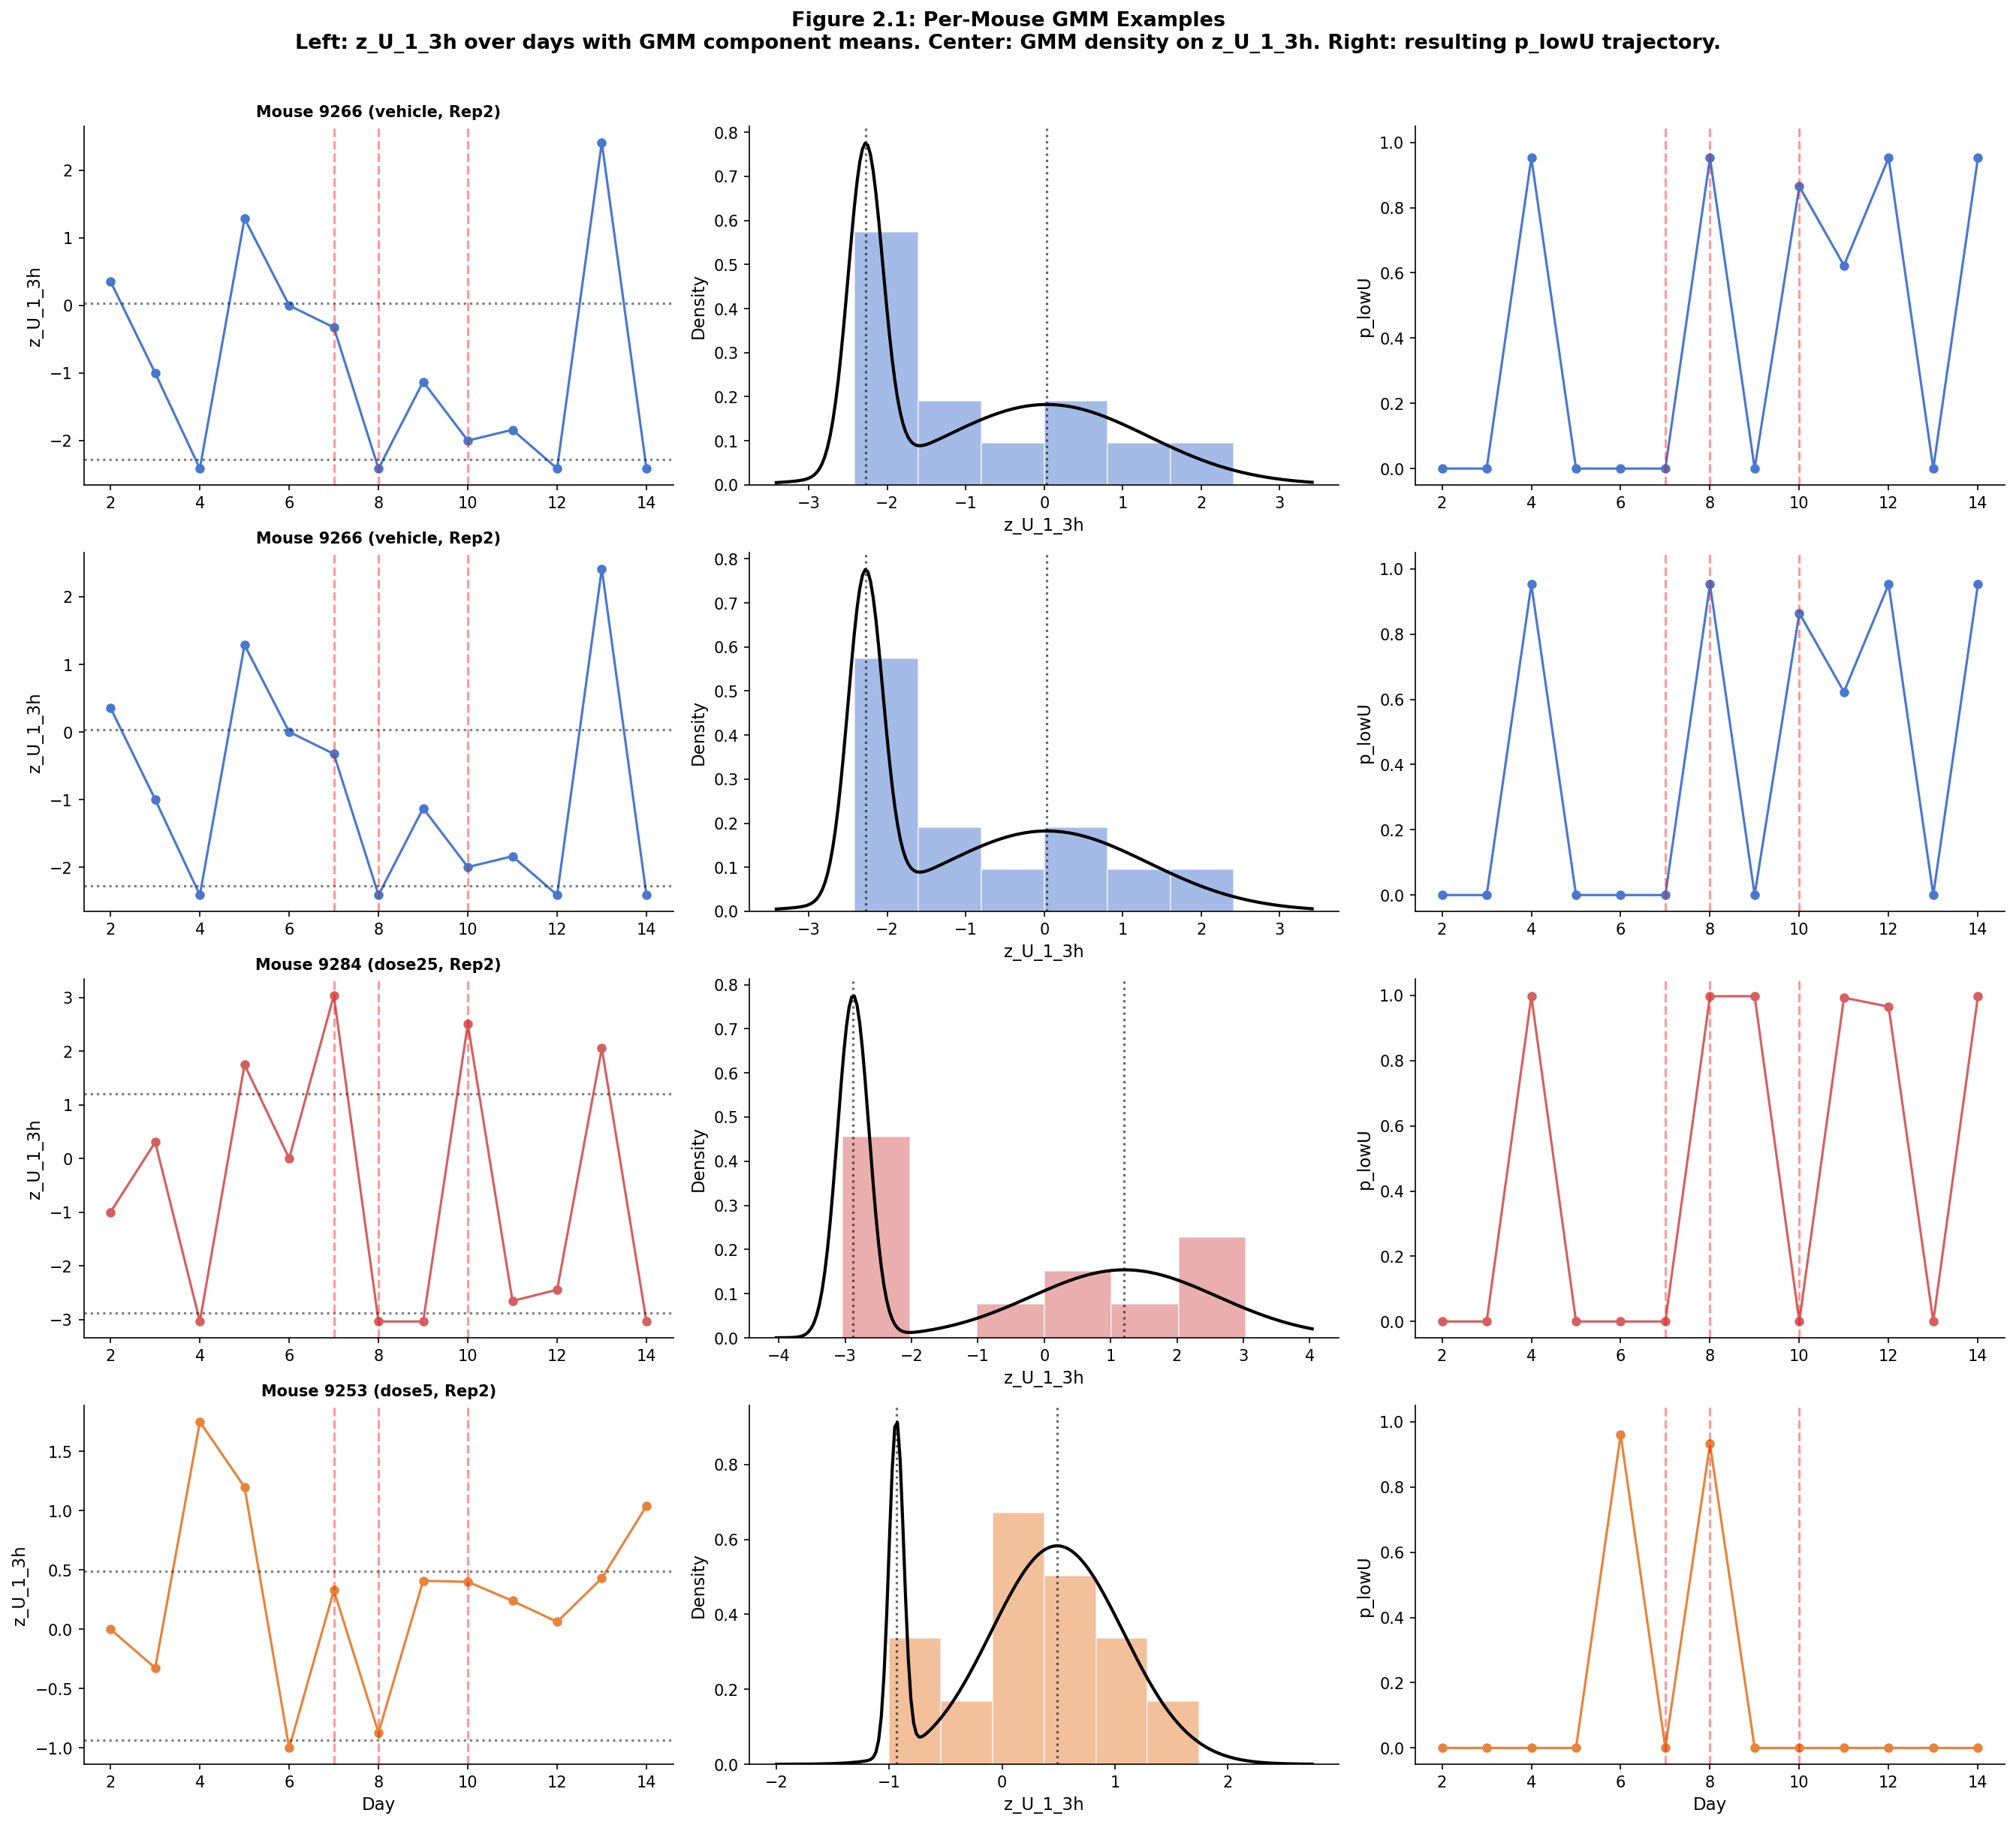

In [12]:
# =============================================================================
# Figure 2.1: GMM Example Mice -- z_U trajectory + GMM fit + p_lowU
# =============================================================================
top_mouse = indiv_df.dropna(subset=["p_shuffle_all"]).nsmallest(1, "p_shuffle_all").iloc[0]
worst_mouse = indiv_df.dropna(subset=["p_shuffle_all"]).nlargest(1, "p_shuffle_all").iloc[0]
veh_mouse = indiv_df[indiv_df["group"]=="vehicle"].iloc[len(indiv_df[indiv_df["group"]=="vehicle"])//2]
d25_mouse = indiv_df[indiv_df["group"]=="dose25"].iloc[len(indiv_df[indiv_df["group"]=="dose25"])//2]
example_mice = [top_mouse, veh_mouse, d25_mouse, worst_mouse]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle("Figure 2.1: Per-Mouse GMM Examples\n"
             "Left: z_U_1_3h over days with GMM component means. "
             "Center: GMM density on z_U_1_3h. "
             "Right: resulting p_lowU trajectory.",
             fontsize=13, fontweight="bold", y=1.01)

for row_i, mouse_row in enumerate(example_mice):
    g, r, aid = mouse_row["group"], mouse_row["replicate"], int(mouse_row["animal_id"])
    sub = feat_qc[(feat_qc["animal_id"] == aid) & (feat_qc["group"] == g) & (feat_qc["replicate"] == r)].sort_values("day")
    cfg = GROUPS[g][r]
    label = f"Mouse {aid} ({g}, {r})"

    # Left
    ax = axes[row_i, 0]
    ax.plot(sub["day"], sub["z_U_1_3h"], marker="o", color=GROUP_COLORS.get(g, "gray"), linewidth=1.5, markersize=5)
    if (g, r, aid) in gmm_objects:
        gmm = gmm_objects[(g, r, aid)]
        means = gmm.means_.flatten()
        for m_val in means:
            ax.axhline(m_val, linestyle=":", alpha=0.5, color="black")
    for ed in sorted(cfg["event_days"]):
        ax.axvline(ed, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("z_U_1_3h")
    ax.set_title(label, fontsize=10, fontweight="bold")
    if row_i == 3:
        ax.set_xlabel("Day")

    # Center
    ax = axes[row_i, 1]
    x_vals = sub["z_U_1_3h"].values
    ax.hist(x_vals, bins=min(12, max(5, len(x_vals)//2)), density=True, alpha=0.5,
            color=GROUP_COLORS.get(g, "gray"), edgecolor="white")
    if (g, r, aid) in gmm_objects:
        gmm = gmm_objects[(g, r, aid)]
        x_grid = np.linspace(x_vals.min() - 1, x_vals.max() + 1, 200).reshape(-1, 1)
        log_dens = gmm.score_samples(x_grid)
        ax.plot(x_grid, np.exp(log_dens), color="black", linewidth=2)
        for k in range(2):
            ax.axvline(gmm.means_[k, 0], linestyle=":", color="black", alpha=0.6)
    ax.set_xlabel("z_U_1_3h")
    ax.set_ylabel("Density")

    # Right
    ax = axes[row_i, 2]
    ax.plot(sub["day"], sub["p_lowU"], marker="o", color=GROUP_COLORS.get(g, "gray"), linewidth=1.5, markersize=5)
    ax.set_ylim(-0.05, 1.05)
    for ed in sorted(cfg["event_days"]):
        ax.axvline(ed, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("p_lowU")
    if row_i == 3:
        ax.set_xlabel("Day")

plt.tight_layout()
plt.show()


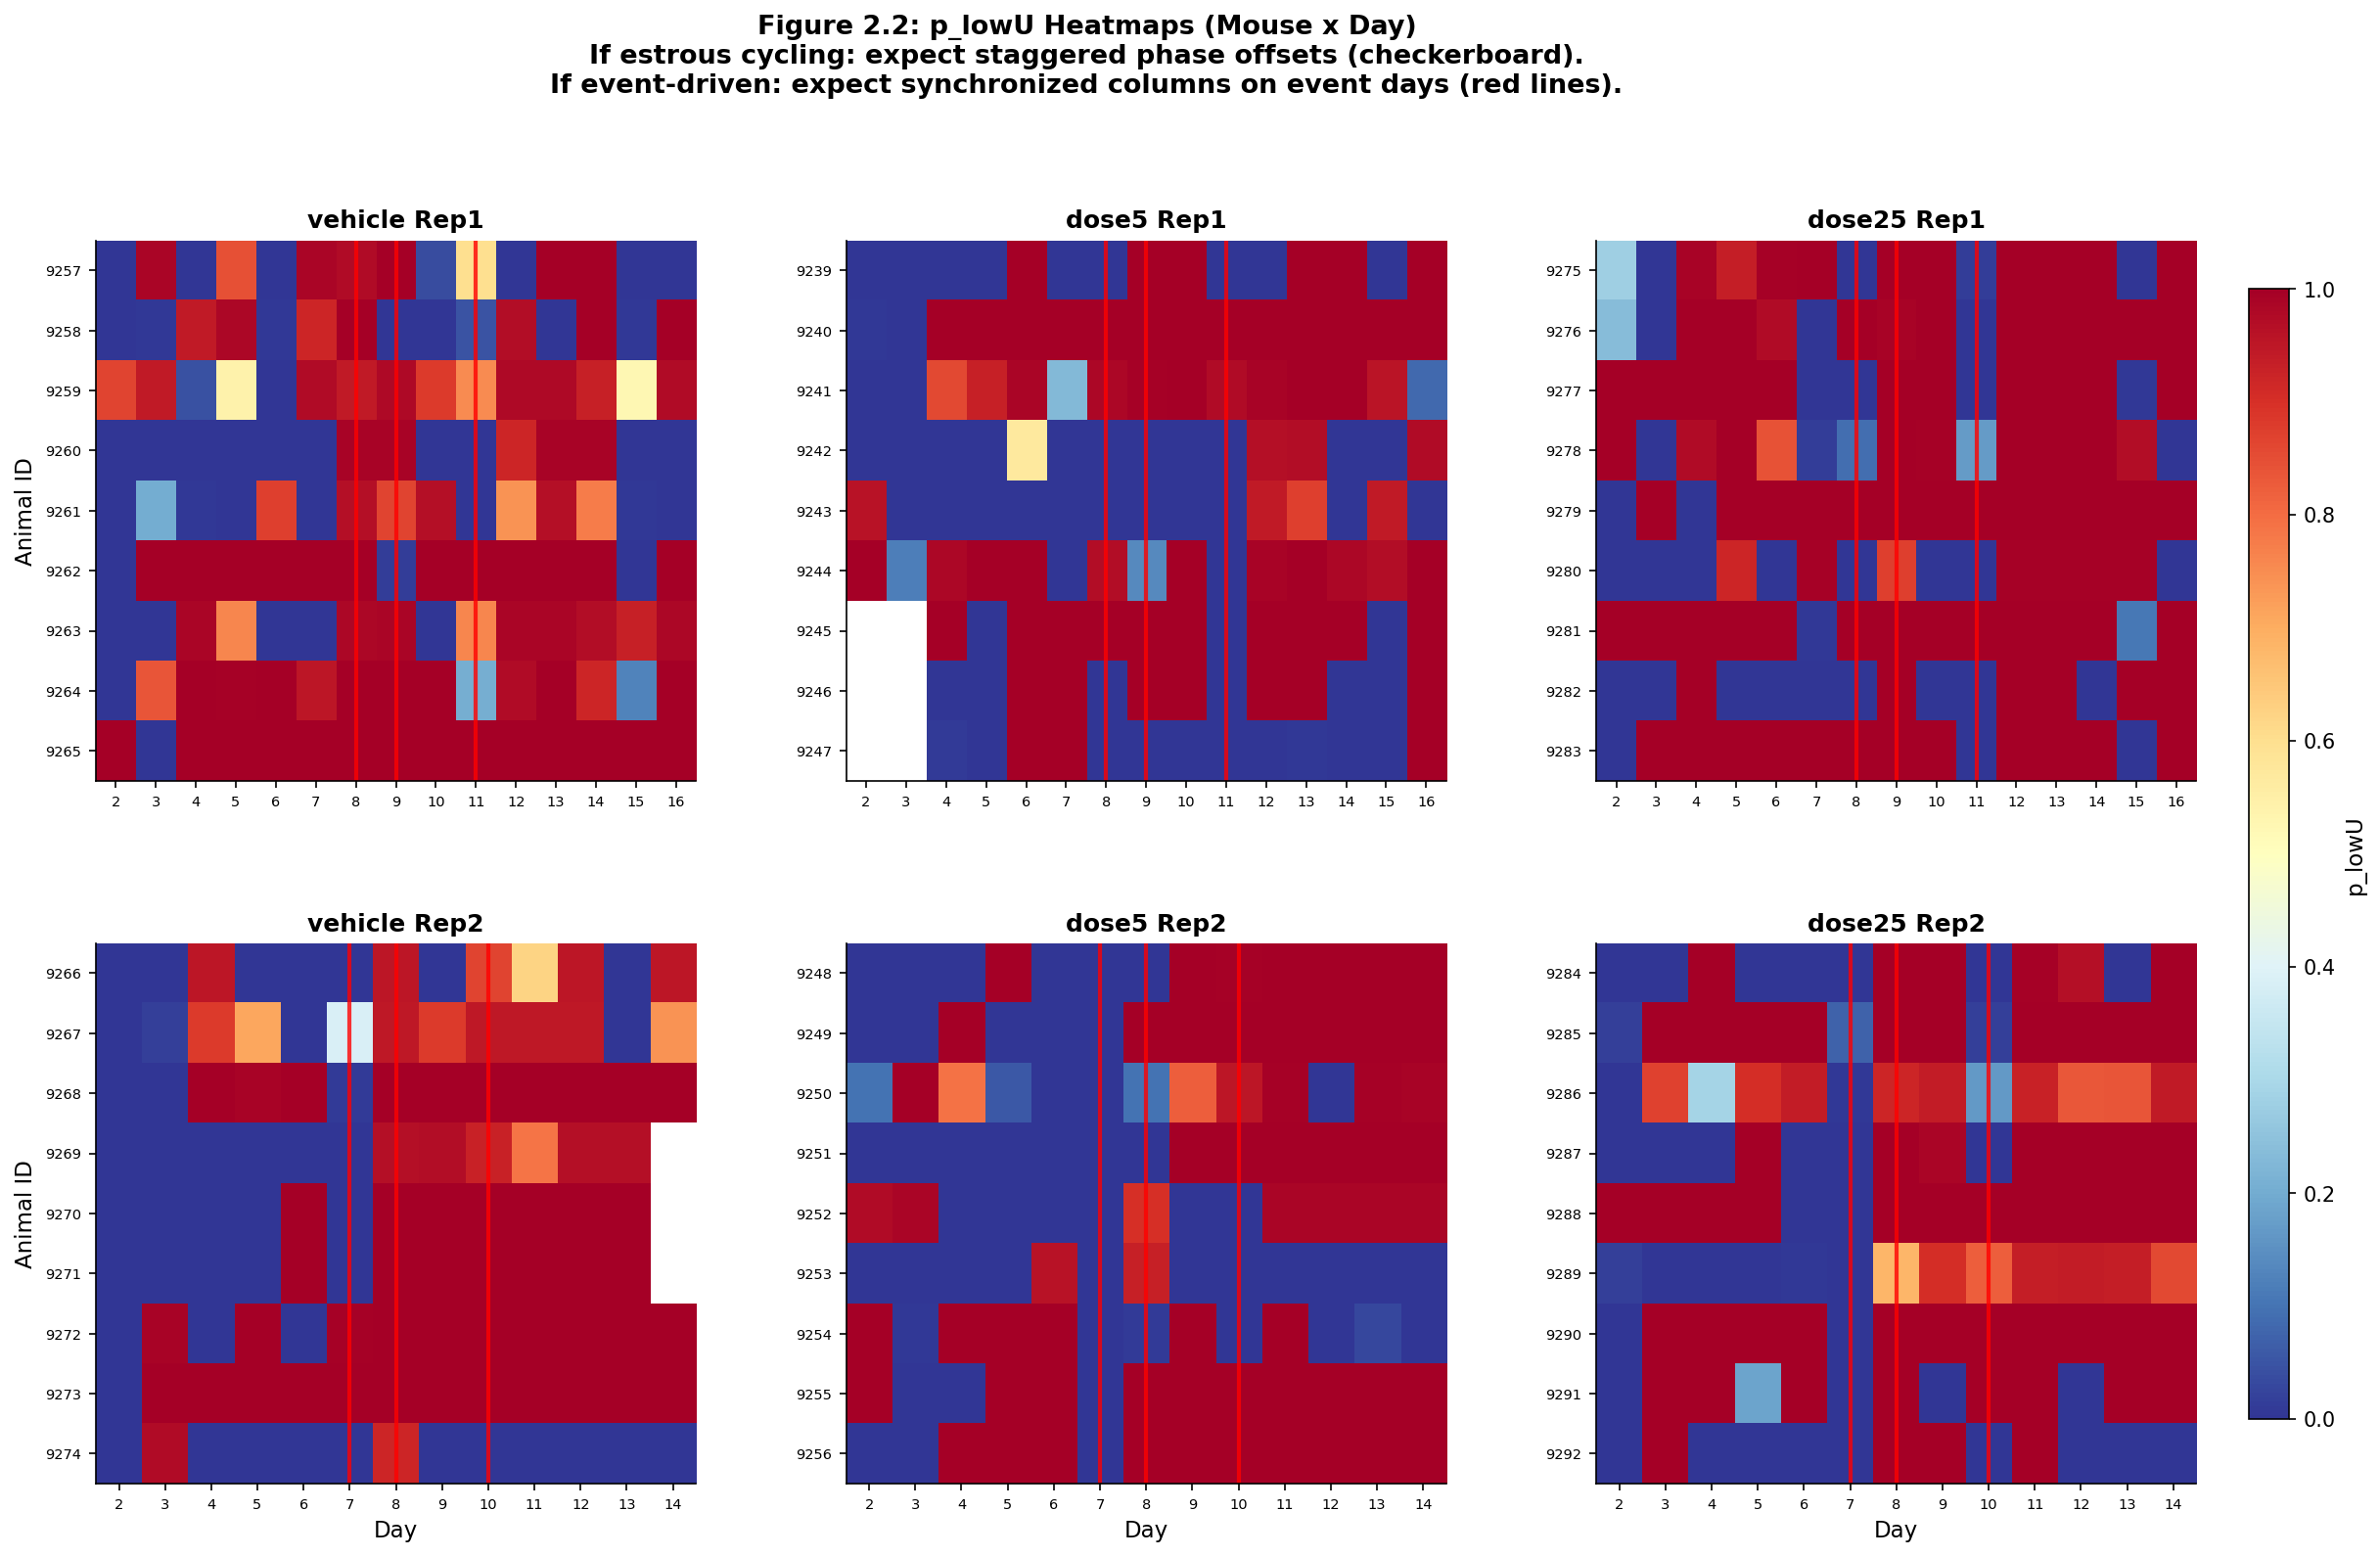

In [13]:
# =============================================================================
# Figure 2.2: p_lowU Heatmaps (Mouse x Day) -- All Groups/Reps
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Figure 2.2: p_lowU Heatmaps (Mouse x Day)\n"
             "If estrous cycling: expect staggered phase offsets (checkerboard).\n"
             "If event-driven: expect synchronized columns on event days (red lines).",
             fontsize=13, fontweight="bold", y=1.02)

for i, group in enumerate(["vehicle", "dose5", "dose25"]):
    for j, rep in enumerate(["Rep1", "Rep2"]):
        ax = axes[j, i]
        sub = feat_qc[(feat_qc["group"] == group) & (feat_qc["replicate"] == rep)]
        if len(sub) == 0:
            ax.set_title(f"{group} {rep}")
            continue

        heat = sub.pivot_table(index="animal_id", columns="day", values="p_lowU", aggfunc="mean").sort_index()
        im = ax.imshow(heat.values, aspect="auto", interpolation="nearest", vmin=0, vmax=1, cmap="RdYlBu_r")
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels([str(a) for a in heat.index], fontsize=7)
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels([str(d) for d in heat.columns], fontsize=7)

        cfg = GROUPS[group][rep]
        for ed in sorted(cfg["event_days"]):
            if ed in heat.columns:
                ax.axvline(list(heat.columns).index(ed), color="red", linewidth=2, alpha=0.8)

        ax.set_title(f"{group} {rep}", fontweight="bold")
        if j == 1:
            ax.set_xlabel("Day")
        if i == 0:
            ax.set_ylabel("Animal ID")

fig.subplots_adjust(right=0.92, hspace=0.3, wspace=0.25)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="p_lowU")
plt.show()


---
# Act 3: Does Any Individual Mouse Show Cyclicity?


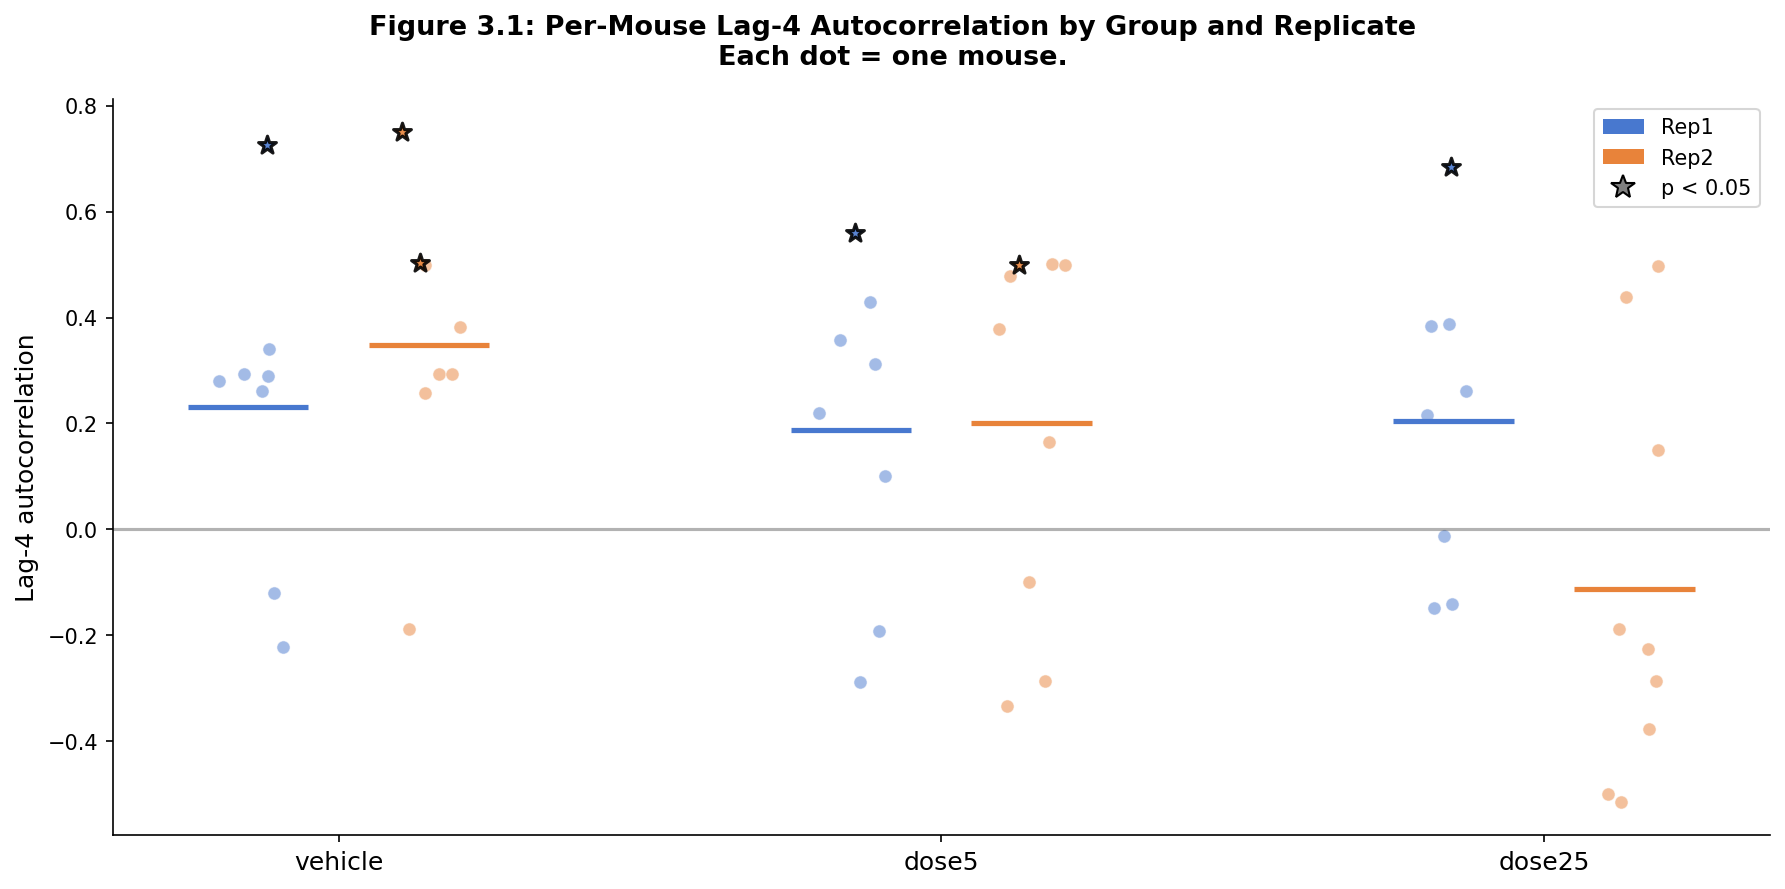

In [14]:
# =============================================================================
# Figure 3.1: Per-Mouse Autocorrelation Strip Plot by Replicate
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Figure 3.1: Per-Mouse Lag-4 Autocorrelation by Group and Replicate\n"
             "Each dot = one mouse.",
             fontsize=13, fontweight="bold")

groups_ordered = ["vehicle", "dose5", "dose25"]
rng_jitter = np.random.default_rng(42)

for i, g in enumerate(groups_ordered):
    for j, rep in enumerate(["Rep1", "Rep2"]):
        sub = indiv_df[(indiv_df["group"] == g) & (indiv_df["replicate"] == rep)]
        valid = sub["autocorr_all"].notna()
        vals = sub.loc[valid, "autocorr_all"].values
        sig_mask = sub.loc[valid, "p_shuffle_all"].values < 0.05
        x_base = i + (j - 0.5) * 0.3
        jitter = rng_jitter.uniform(-0.06, 0.06, len(vals))

        ax.scatter(np.full(np.sum(~sig_mask), x_base) + jitter[~sig_mask],
                   vals[~sig_mask], color=REP_COLORS[rep], alpha=0.5, s=40,
                   edgecolors="white", linewidth=0.5)

        if np.any(sig_mask):
            ax.scatter(np.full(np.sum(sig_mask), x_base) + jitter[sig_mask],
                       vals[sig_mask], color=REP_COLORS[rep], alpha=0.9, s=80,
                       edgecolors="black", linewidth=1.5, marker="*", zorder=5)

        ax.hlines(np.nanmean(vals), x_base - 0.1, x_base + 0.1, color=REP_COLORS[rep], linewidth=2.5)

ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.set_xticks(range(len(groups_ordered)))
ax.set_xticklabels(groups_ordered, fontsize=12)
ax.set_ylabel("Lag-4 autocorrelation", fontsize=12)

legend_elements = [
    Patch(facecolor=REP_COLORS["Rep1"], label="Rep1"),
    Patch(facecolor=REP_COLORS["Rep2"], label="Rep2"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray",
           markeredgecolor="black", markersize=12, label="p < 0.05"),
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()


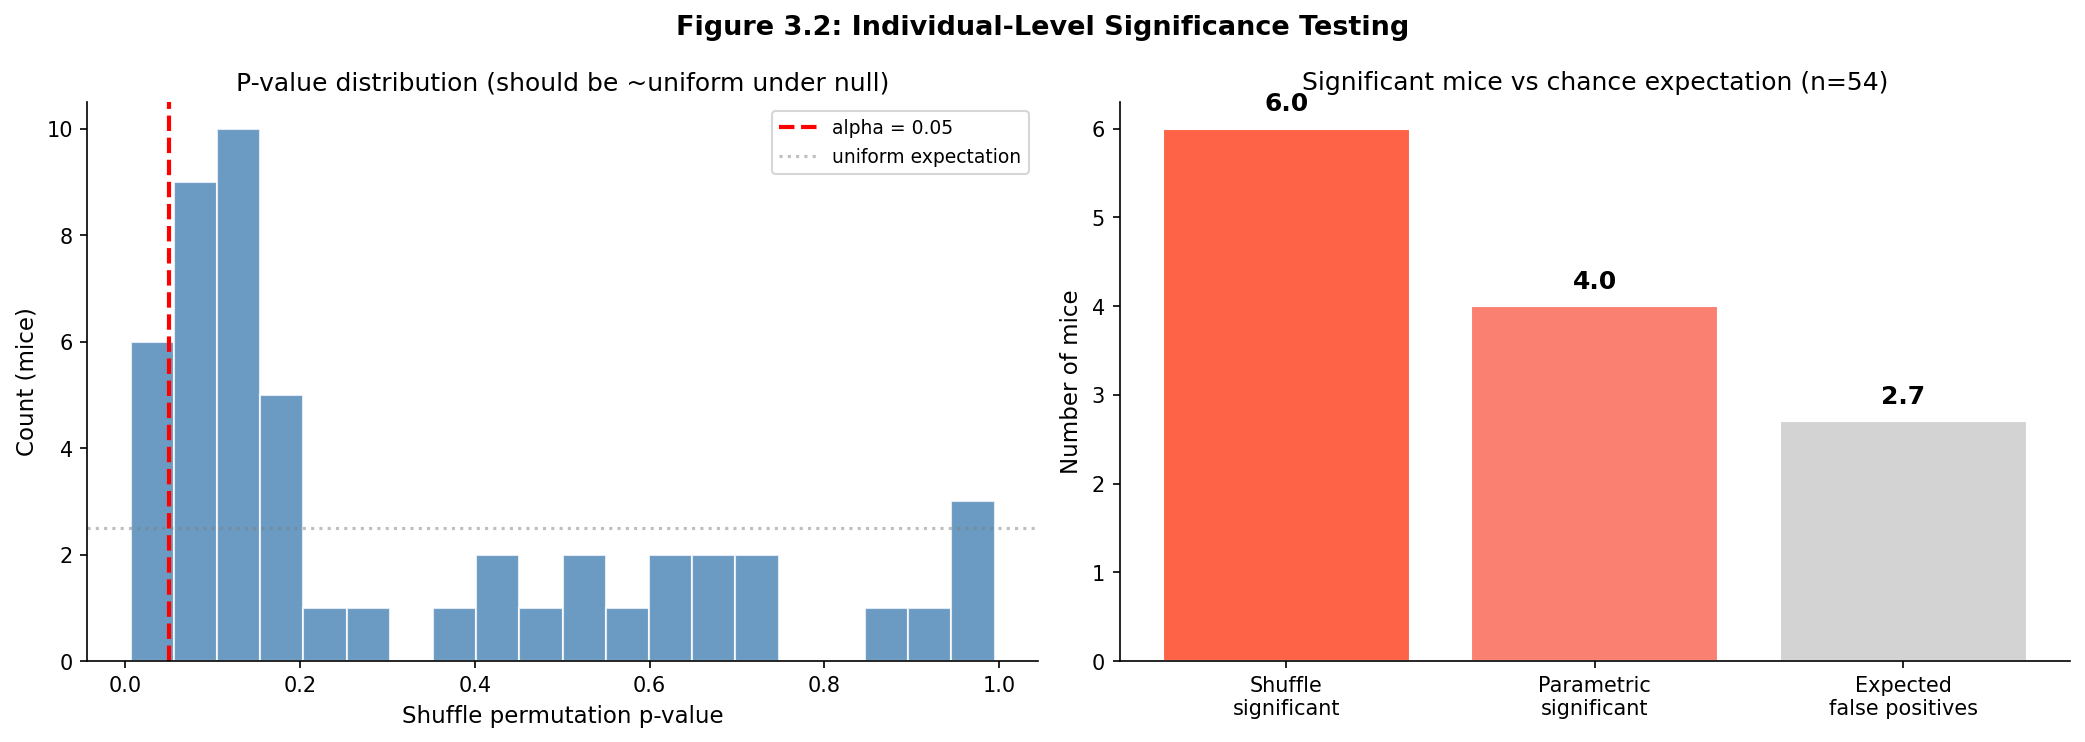

In [15]:
# =============================================================================
# Figure 3.2: Shuffle P-Value Distribution + Significance Count
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3.2: Individual-Level Significance Testing",
             fontsize=13, fontweight="bold")

ax = axes[0]
pvals = indiv_df["p_shuffle_all"].dropna()
ax.hist(pvals, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0.05, color="red", linewidth=2, linestyle="--", label="alpha = 0.05")
ax.axhline(len(pvals)/20, color="gray", linestyle=":", alpha=0.5, label="uniform expectation")
ax.set_xlabel("Shuffle permutation p-value")
ax.set_ylabel("Count (mice)")
ax.set_title("P-value distribution (should be ~uniform under null)")
ax.legend(fontsize=9)

ax = axes[1]
n_total = len(indiv_df)
n_sig_shuf = int((indiv_df["p_shuffle_all"] < 0.05).sum())
n_sig_param = int((indiv_df["p_param_all"] < 0.05).sum())
exp_fp = n_total * 0.05

bars = ax.bar(["Shuffle\nsignificant", "Parametric\nsignificant", "Expected\nfalse positives"],
              [n_sig_shuf, n_sig_param, exp_fp],
              color=["tomato", "salmon", "lightgray"], edgecolor="white")
for bar, val in zip(bars, [n_sig_shuf, n_sig_param, exp_fp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of mice")
ax.set_title(f"Significant mice vs chance expectation (n={n_total})")

plt.tight_layout()
plt.show()


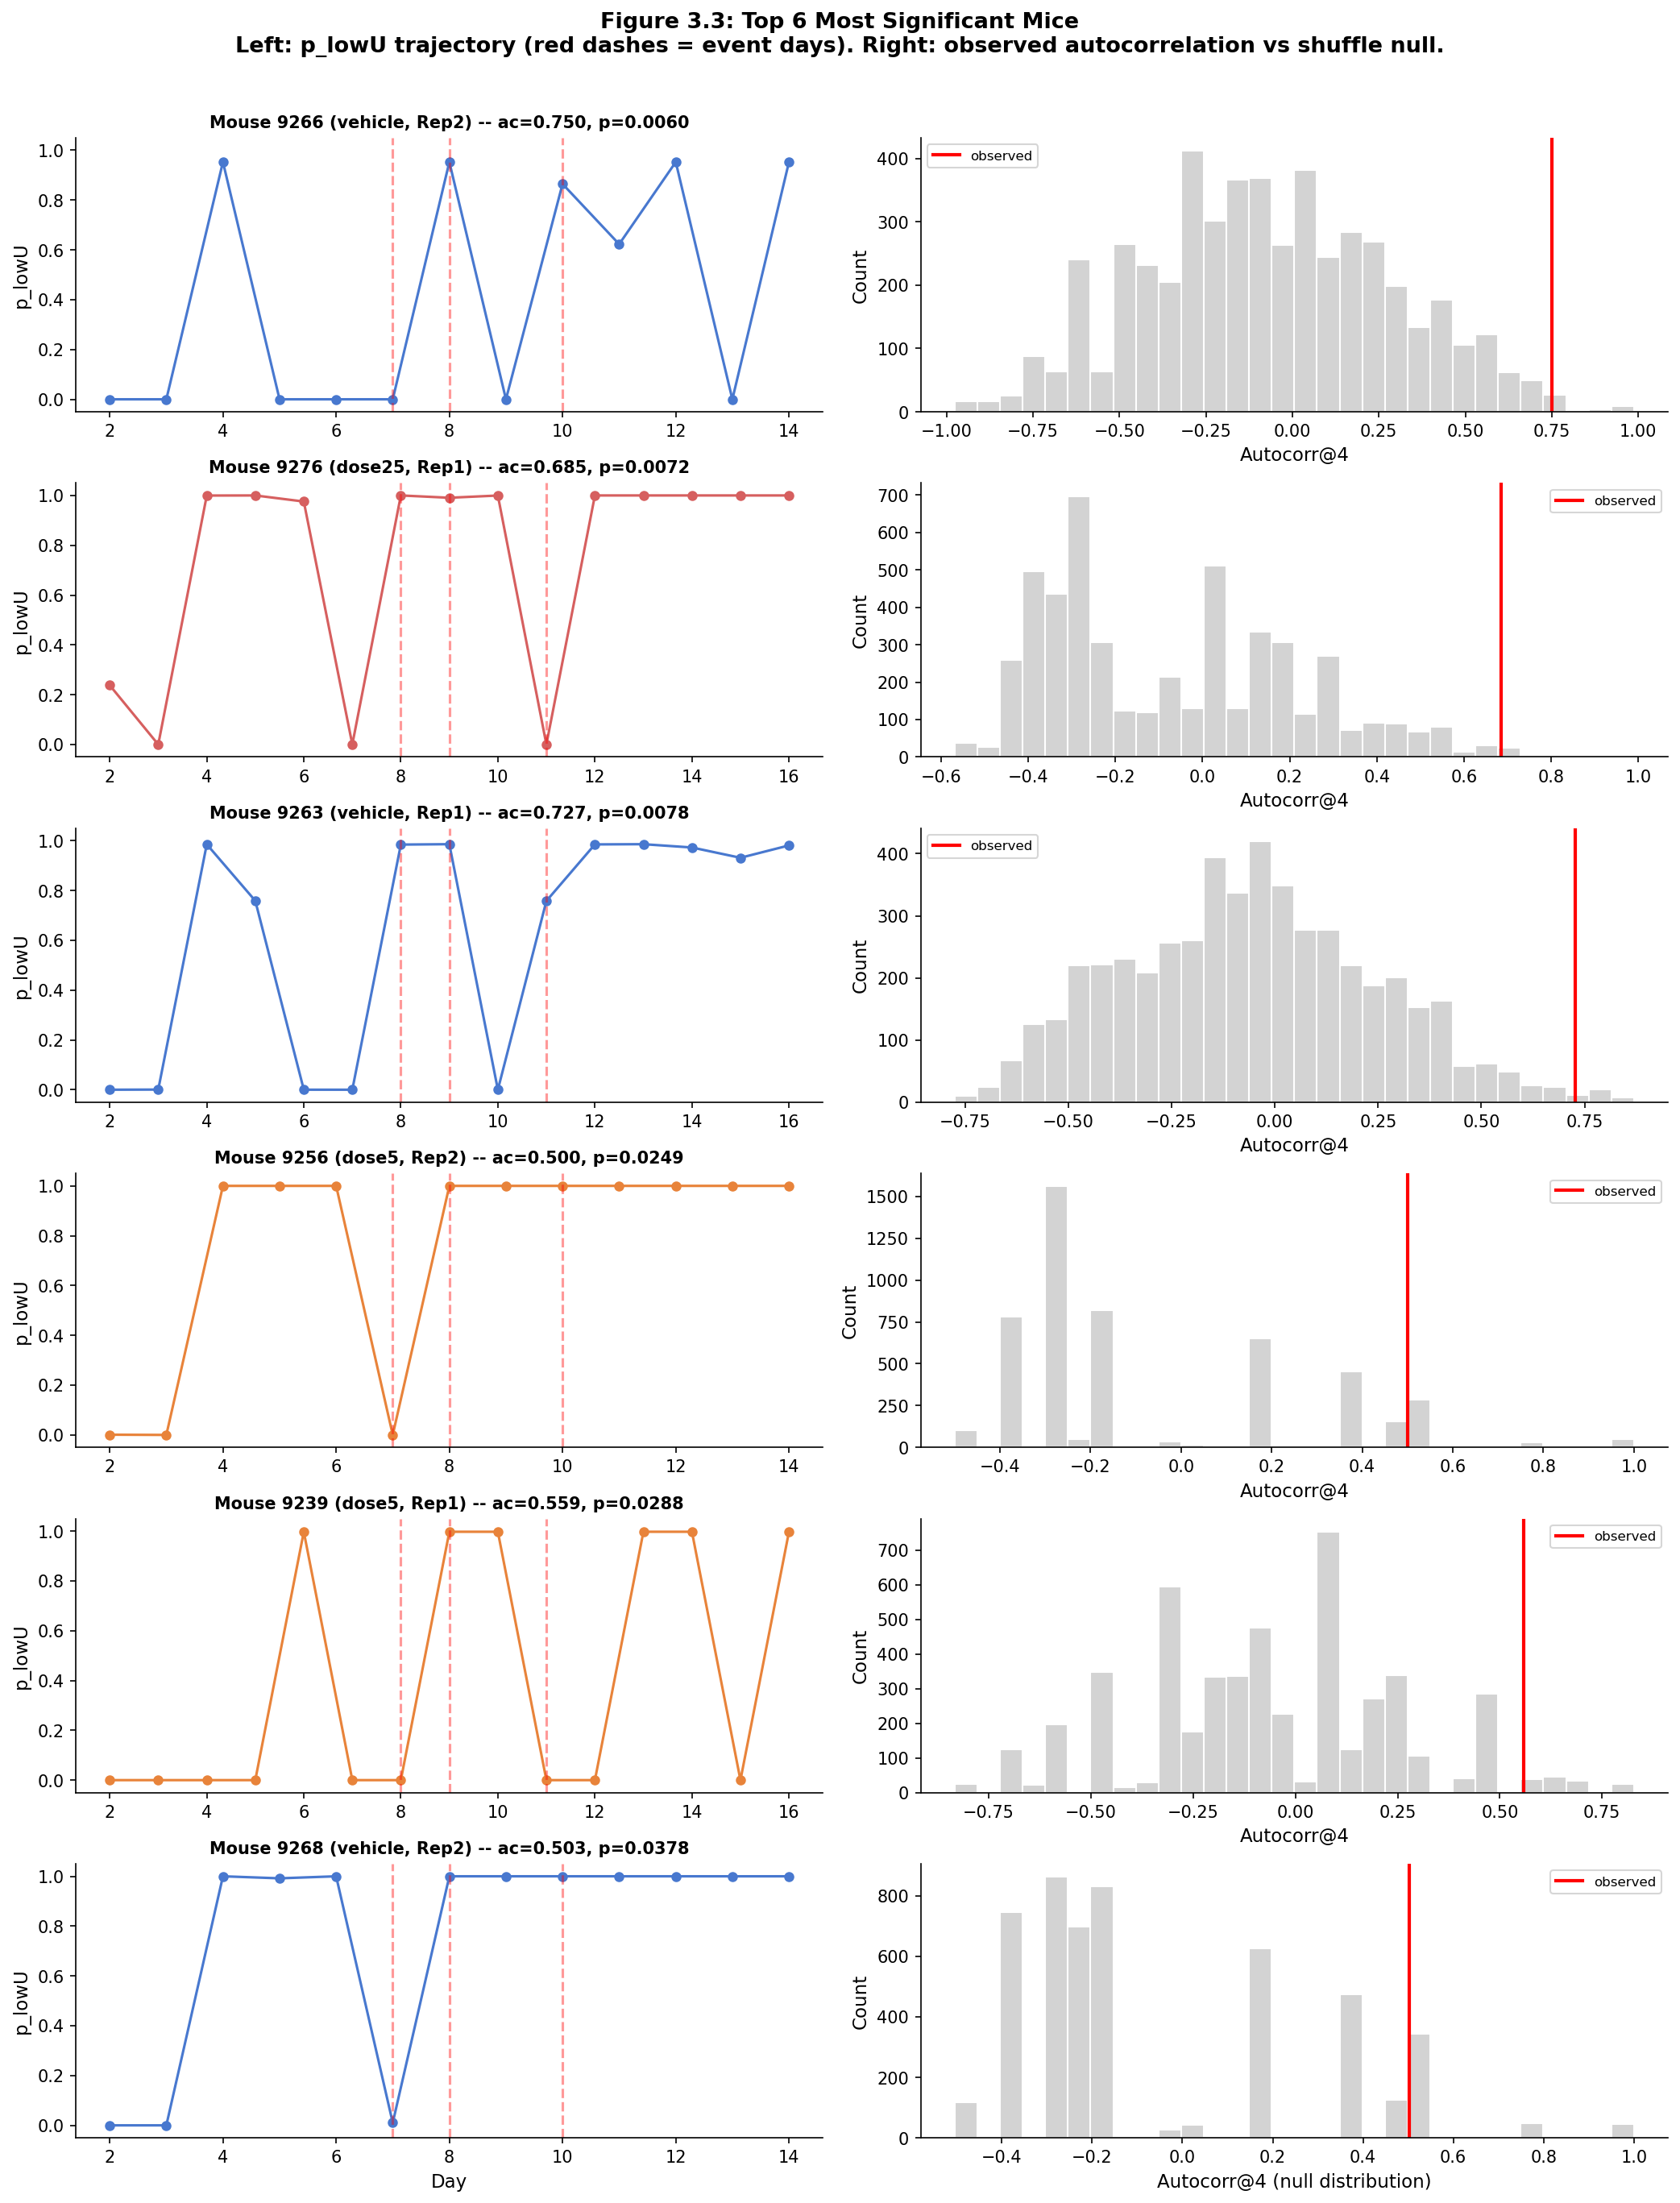

In [16]:
# =============================================================================
# Figure 3.3: Top Significant Mice -- p_lowU Trajectories + Null Distributions
# =============================================================================
top_n = 6
top_mice = indiv_df.dropna(subset=["p_shuffle_all"]).nsmallest(top_n, "p_shuffle_all")

fig, axes = plt.subplots(top_n, 2, figsize=(14, top_n * 3))
fig.suptitle(f"Figure 3.3: Top {top_n} Most Significant Mice\n"
             "Left: p_lowU trajectory (red dashes = event days). "
             "Right: observed autocorrelation vs shuffle null.",
             fontsize=13, fontweight="bold", y=1.01)

for row_i, (_, mrow) in enumerate(top_mice.iterrows()):
    g, r, aid = mrow["group"], mrow["replicate"], int(mrow["animal_id"])
    sub = feat_qc[(feat_qc["animal_id"] == aid) & (feat_qc["group"] == g) & (feat_qc["replicate"] == r)].sort_values("day")
    cfg = GROUPS[g][r]

    ax = axes[row_i, 0]
    ax.plot(sub["day"], sub["p_lowU"], marker="o", color=GROUP_COLORS.get(g, "gray"), linewidth=1.5, markersize=5)
    for ed in sorted(cfg["event_days"]):
        ax.axvline(ed, color="red", linestyle="--", alpha=0.4)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("p_lowU")
    ac_str = f"ac={mrow['autocorr_all']:.3f}" if pd.notna(mrow['autocorr_all']) else "ac=nan"
    p_str = f"p={mrow['p_shuffle_all']:.4f}" if pd.notna(mrow['p_shuffle_all']) else "p=nan"
    ax.set_title(f"Mouse {aid} ({g}, {r}) -- {ac_str}, {p_str}", fontsize=10, fontweight="bold")
    if row_i == top_n - 1:
        ax.set_xlabel("Day")

    ax = axes[row_i, 1]
    null = indiv_nulls.get((g, r, aid), np.array([]))
    null_f = null[np.isfinite(null)] if len(null) > 0 else np.array([])
    if len(null_f) > 0:
        ax.hist(null_f, bins=30, color="lightgray", edgecolor="white")
    if pd.notna(mrow["autocorr_all"]):
        ax.axvline(mrow["autocorr_all"], color="red", linewidth=2, label="observed")
    ax.set_xlabel(f"Autocorr@{LAG}")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    if row_i == top_n - 1:
        ax.set_xlabel(f"Autocorr@{LAG} (null distribution)")

plt.tight_layout()
plt.show()


---
# Act 4: What About at the Group Level?


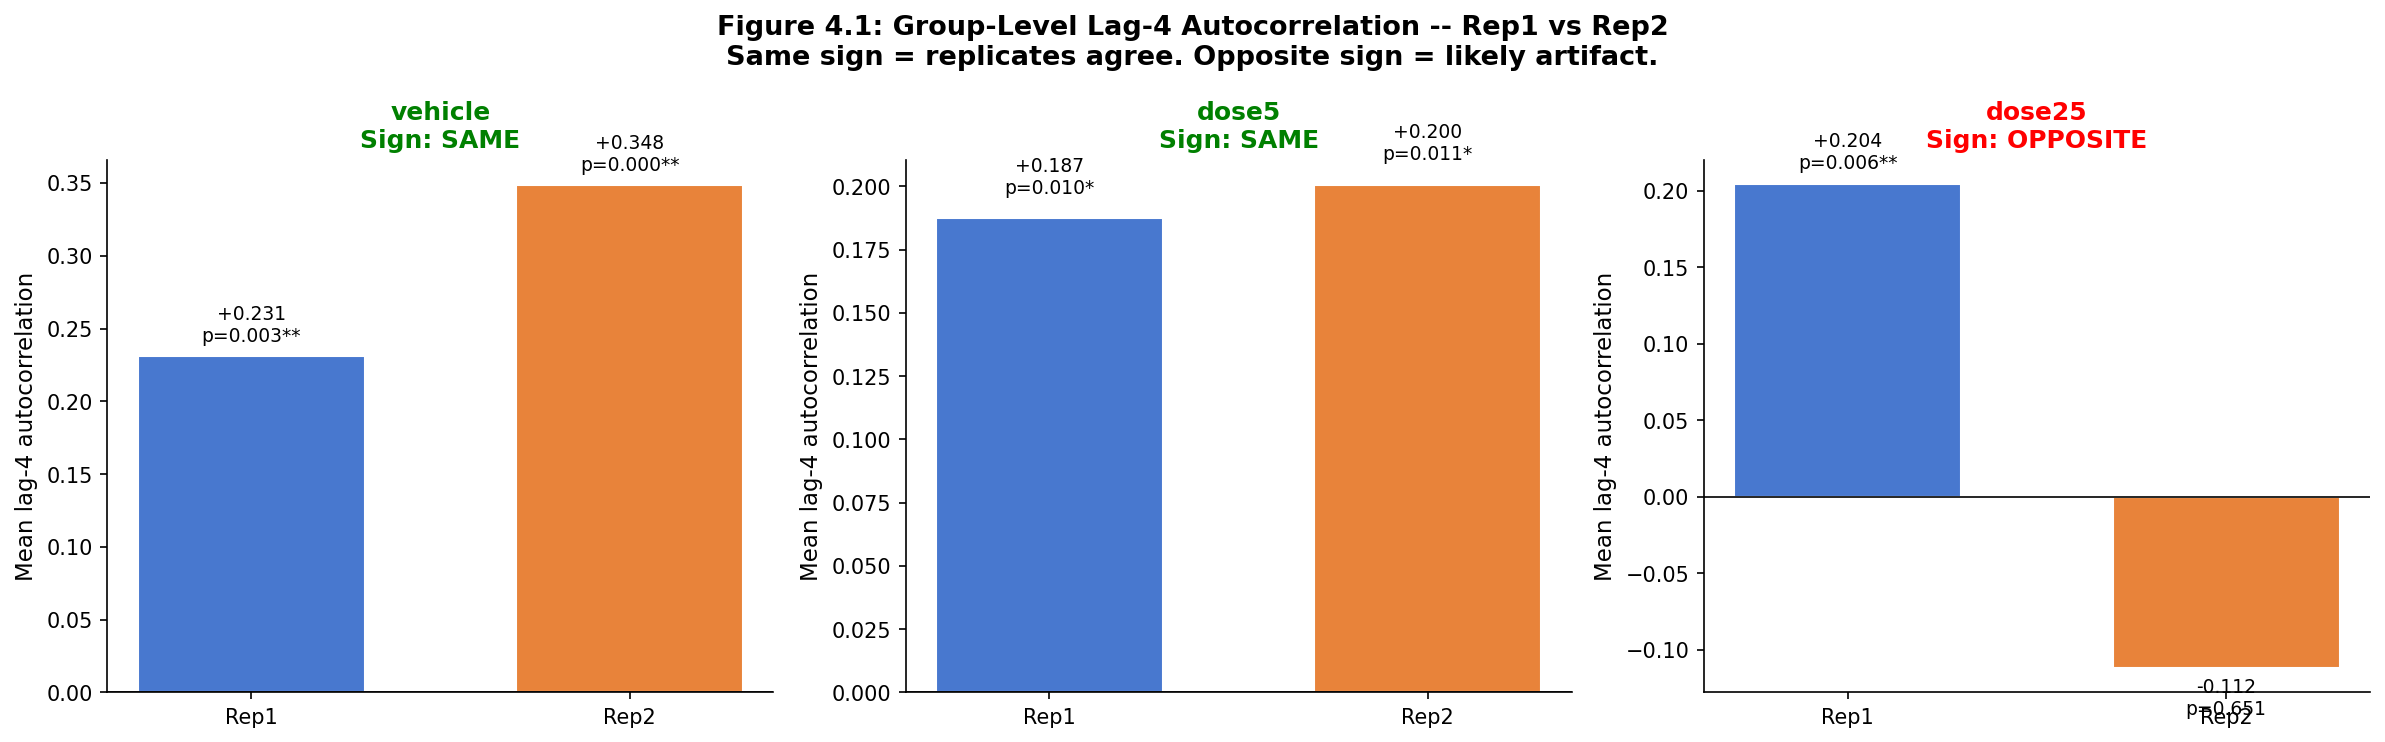

In [17]:
# =============================================================================
# Figure 4.1: Group Mean Autocorrelation -- Rep1 vs Rep2 Side by Side
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 4.1: Group-Level Lag-4 Autocorrelation -- Rep1 vs Rep2\n"
             "Same sign = replicates agree. Opposite sign = likely artifact.",
             fontsize=13, fontweight="bold")

for i, g in enumerate(["vehicle", "dose5", "dose25"]):
    ax = axes[i]
    r1 = group_df[(group_df["group"] == g) & (group_df["replicate"] == "Rep1")]
    r2 = group_df[(group_df["group"] == g) & (group_df["replicate"] == "Rep2")]

    vals = [r1["ac_all"].values[0] if len(r1) > 0 else 0,
            r2["ac_all"].values[0] if len(r2) > 0 else 0]
    pvals = [r1["p_all"].values[0] if len(r1) > 0 else np.nan,
             r2["p_all"].values[0] if len(r2) > 0 else np.nan]

    bars = ax.bar(["Rep1", "Rep2"], vals, color=[REP_COLORS["Rep1"], REP_COLORS["Rep2"]], edgecolor="white", width=0.6)
    ax.axhline(0, color="black", linewidth=0.8)

    for bi, (v, p) in enumerate(zip(vals, pvals)):
        sig = "**" if pd.notna(p) and p < 0.01 else ("*" if pd.notna(p) and p < 0.05 else "")
        ax.text(bi, v + (0.01 if v >= 0 else -0.03),
                f"{v:+.3f}\np={p:.3f}{sig}", ha="center", fontsize=9)

    sign_match = "SAME" if (vals[0] > 0) == (vals[1] > 0) else "OPPOSITE"
    sign_color = "green" if sign_match == "SAME" else "red"
    ax.set_title(f"{g}\nSign: {sign_match}", fontweight="bold", color=sign_color)
    ax.set_ylabel("Mean lag-4 autocorrelation")

plt.tight_layout()
plt.show()


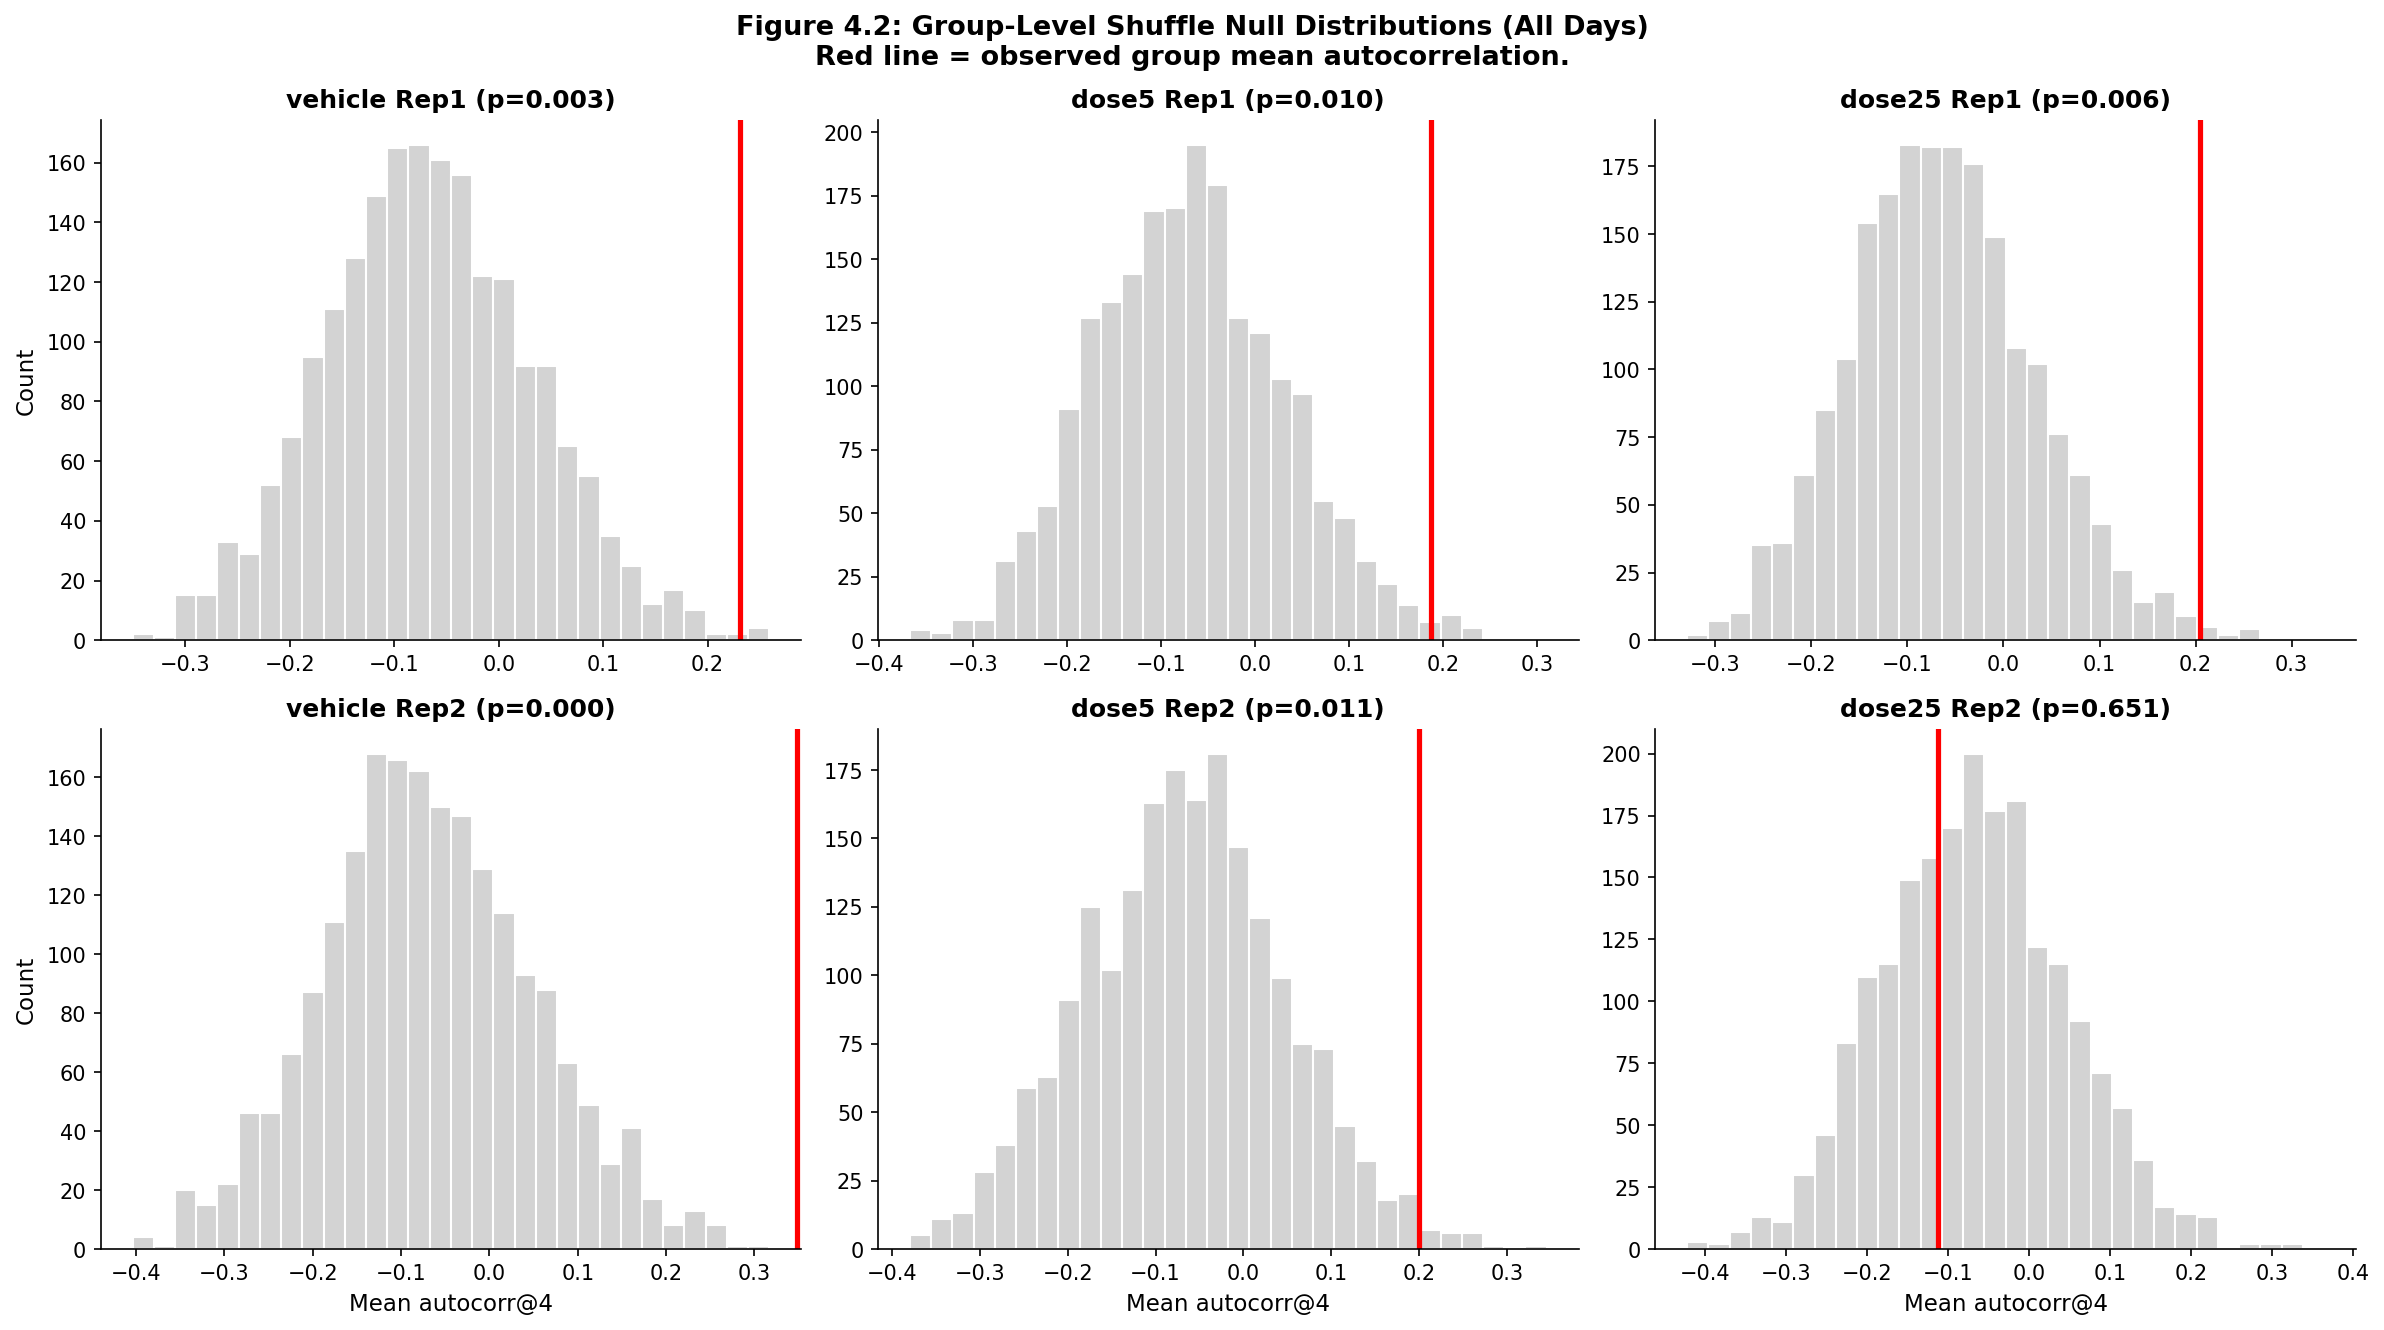

In [18]:
# =============================================================================
# Figure 4.2: Group-Level Null Distributions (All Days)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Figure 4.2: Group-Level Shuffle Null Distributions (All Days)\n"
             "Red line = observed group mean autocorrelation.",
             fontsize=13, fontweight="bold")

for idx, (_, row) in enumerate(group_df.iterrows()):
    g, r = row["group"], row["replicate"]
    col = ["vehicle", "dose5", "dose25"].index(g)
    row_idx = ["Rep1", "Rep2"].index(r)
    ax = axes[row_idx, col]

    null = group_nulls[(g, r)]["all"]
    null_f = null[np.isfinite(null)]
    ax.hist(null_f, bins=30, color="lightgray", edgecolor="white")
    if np.isfinite(row["ac_all"]):
        ax.axvline(row["ac_all"], color="red", linewidth=2.5)
    ax.set_title(f"{g} {r} (p={row['p_all']:.3f})", fontweight="bold")
    if row_idx == 1:
        ax.set_xlabel(f"Mean autocorr@{LAG}")
    if col == 0:
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


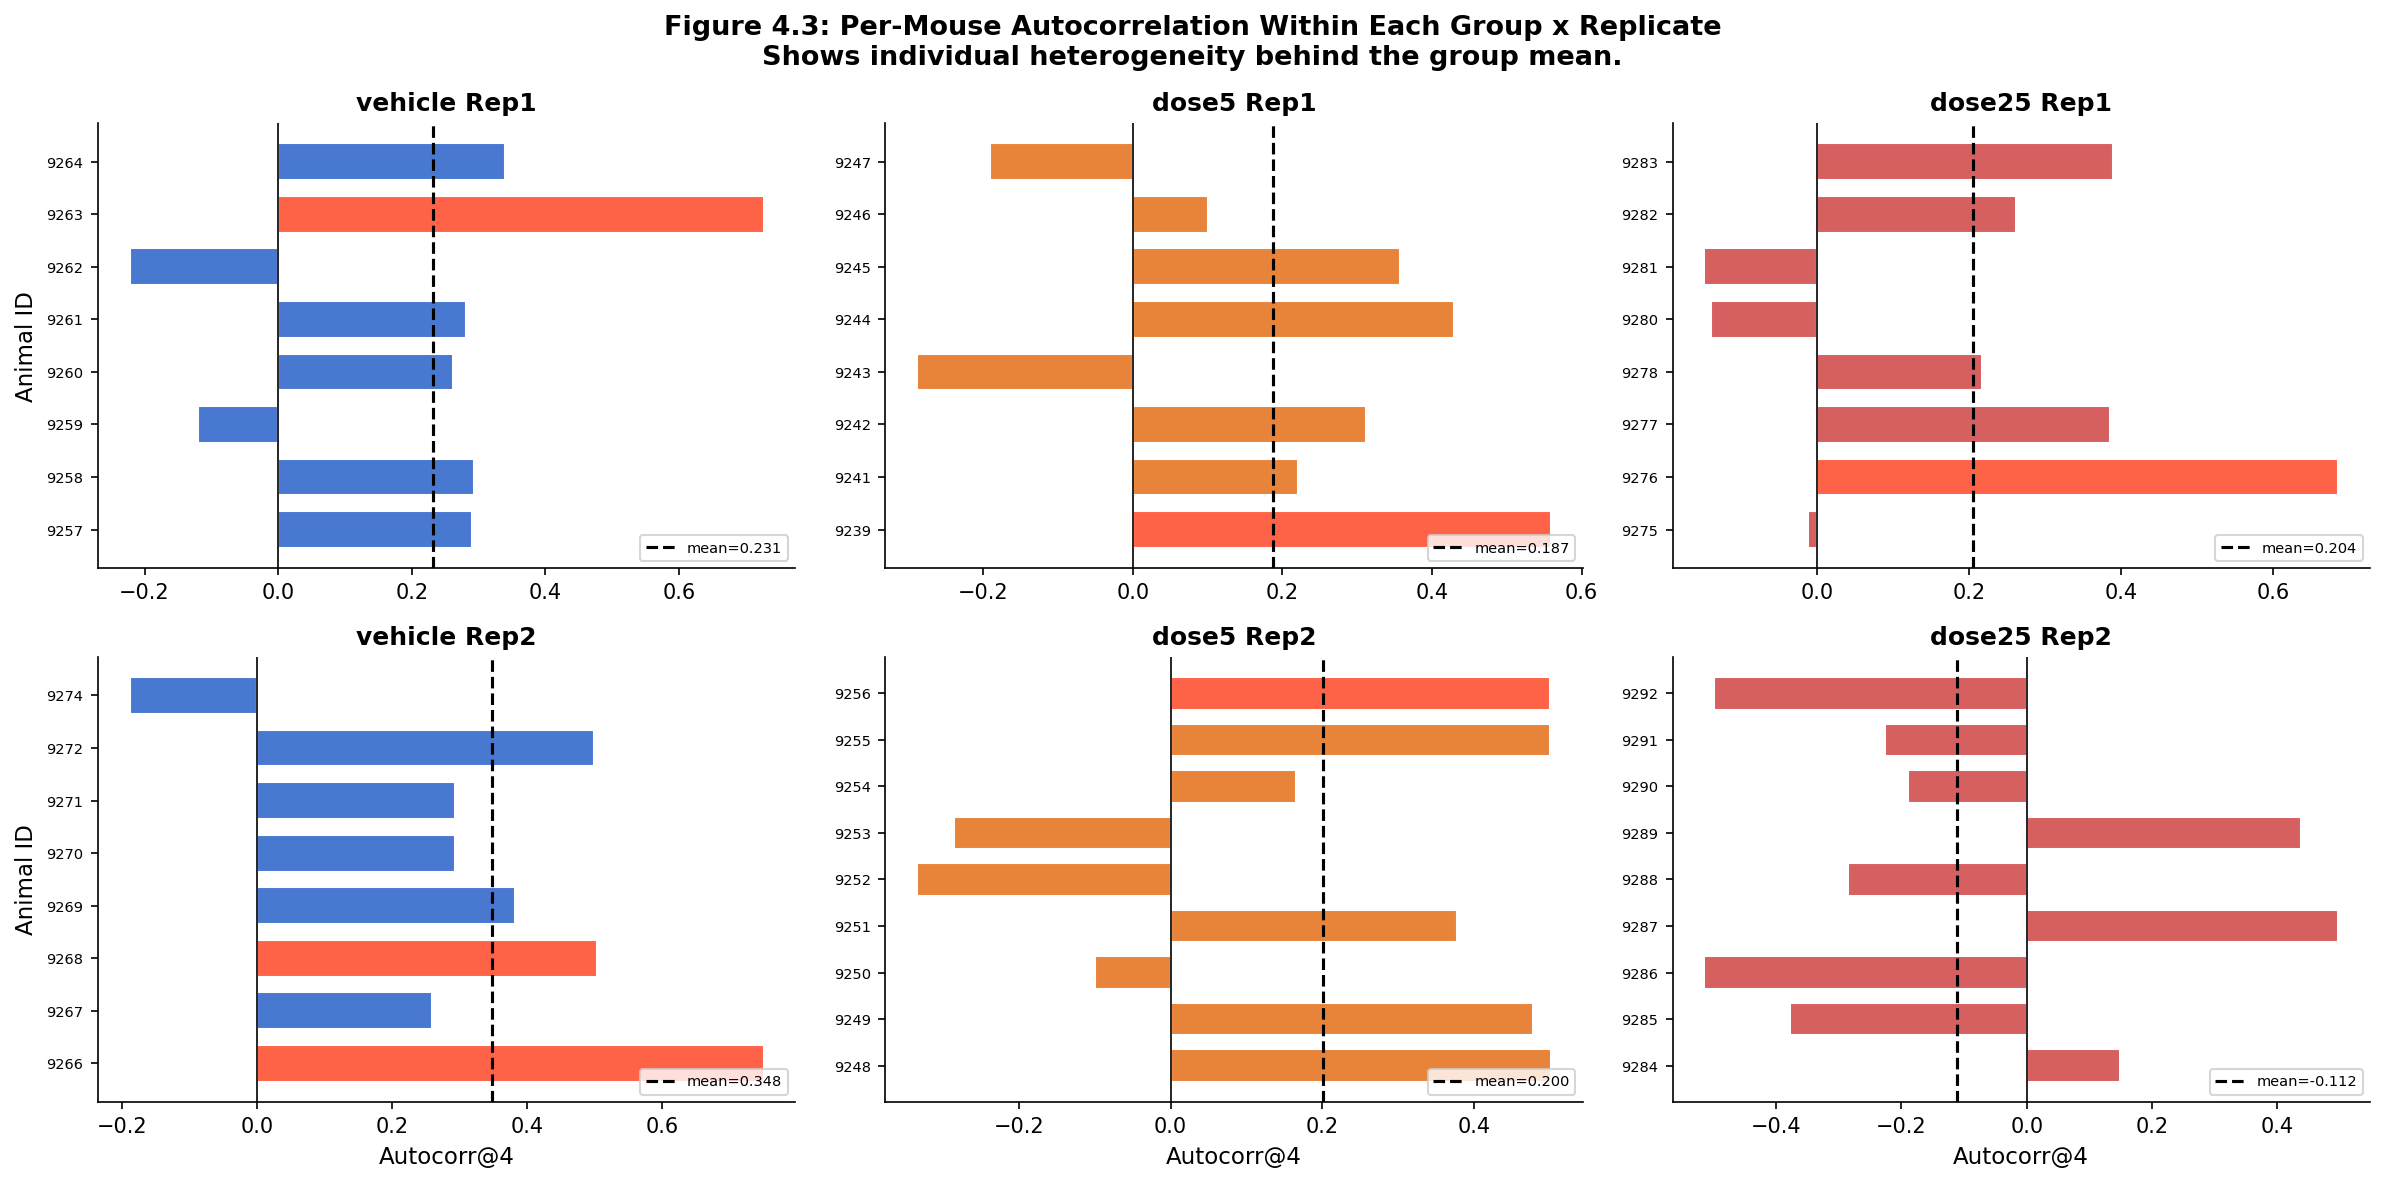

In [19]:
# =============================================================================
# Figure 4.3: Per-Mouse Autocorrelation Within Each Group-Rep
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Figure 4.3: Per-Mouse Autocorrelation Within Each Group x Replicate\n"
             "Shows individual heterogeneity behind the group mean.",
             fontsize=13, fontweight="bold")

for i, g in enumerate(["vehicle", "dose5", "dose25"]):
    for j, rep in enumerate(["Rep1", "Rep2"]):
        ax = axes[j, i]
        sub = indiv_df[(indiv_df["group"] == g) & (indiv_df["replicate"] == rep)]
        vals = sub["autocorr_all"].dropna().values
        aids = sub.loc[sub["autocorr_all"].notna(), "animal_id"].values

        colors = ["tomato" if p < 0.05 else GROUP_COLORS[g]
                  for p in sub.loc[sub["autocorr_all"].notna(), "p_shuffle_all"]]
        ax.barh(range(len(vals)), vals, color=colors, edgecolor="white", height=0.7)
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels([str(int(a)) for a in aids], fontsize=7)
        ax.axvline(0, color="black", linewidth=0.8)

        grp_mean = np.nanmean(vals) if len(vals) else np.nan
        if np.isfinite(grp_mean):
            ax.axvline(grp_mean, color="black", linestyle="--", linewidth=1.5, label=f"mean={grp_mean:.3f}")

        ax.set_title(f"{g} {rep}", fontweight="bold")
        if j == 1:
            ax.set_xlabel(f"Autocorr@{LAG}")
        if i == 0:
            ax.set_ylabel("Animal ID")
        ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()


---
# Act 5: Is the Signal Event-Driven?


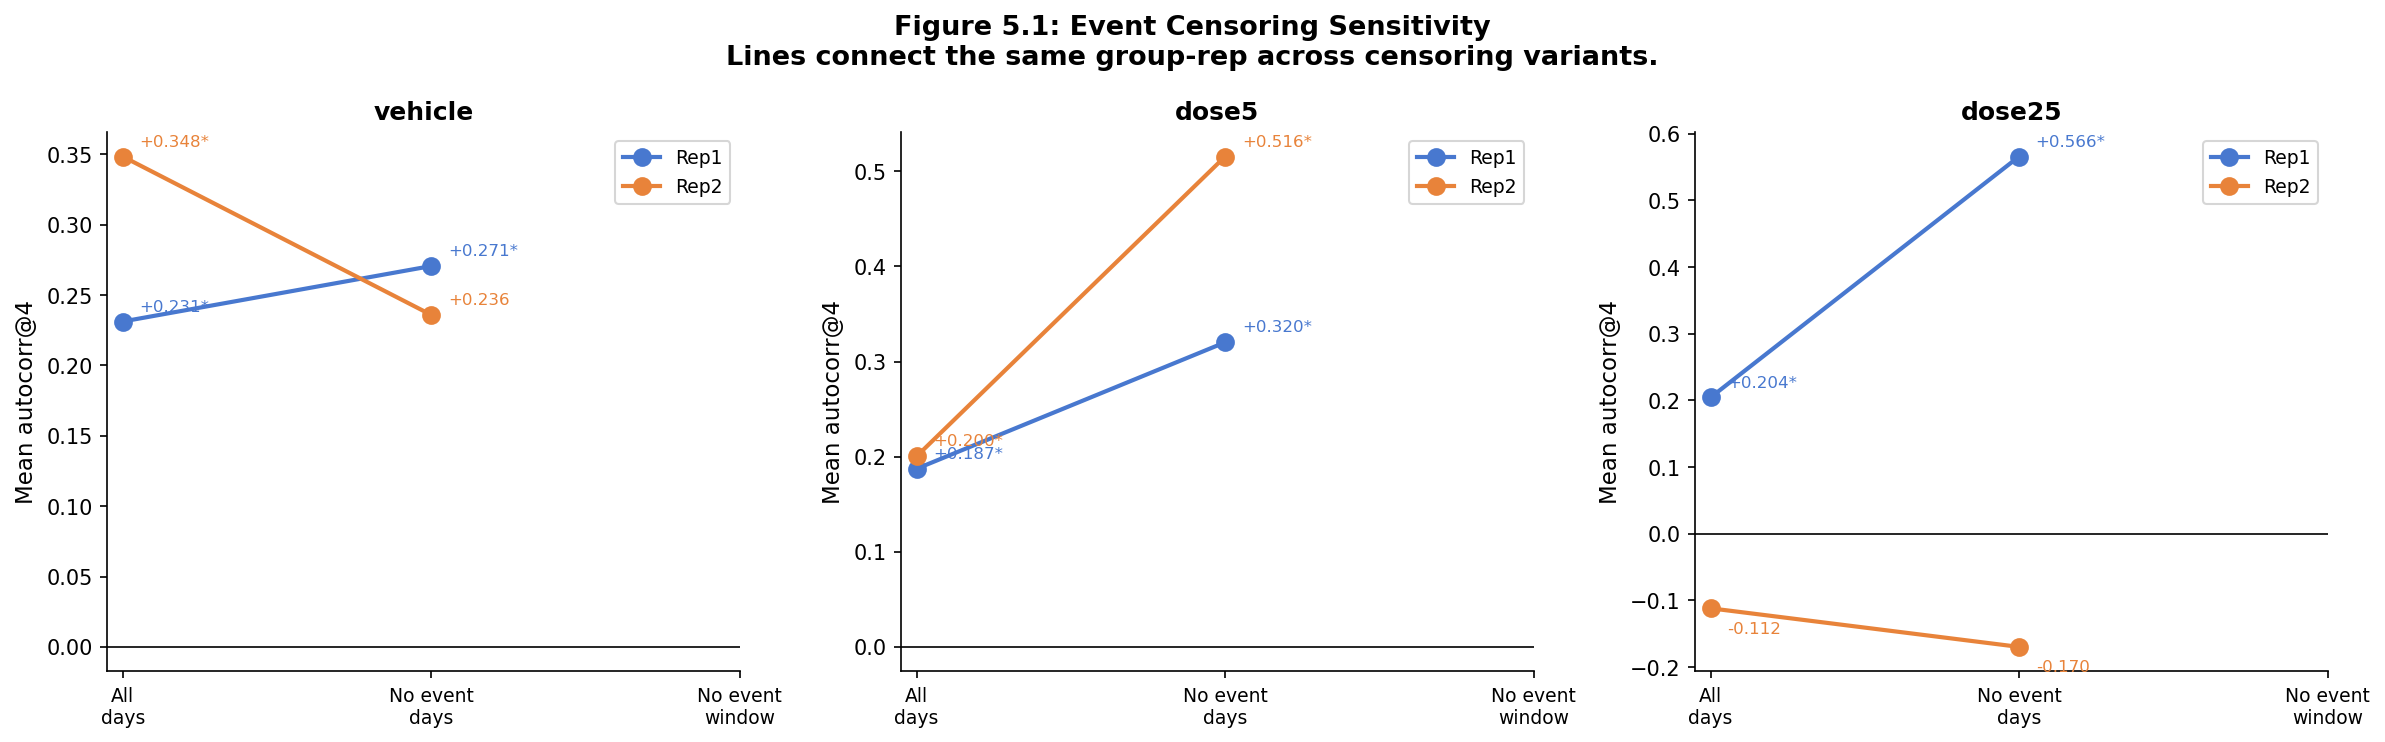

In [20]:
# =============================================================================
# Figure 5.1: Censoring Sensitivity -- Paired Comparison
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 5.1: Event Censoring Sensitivity\n"
             "Lines connect the same group-rep across censoring variants.",
             fontsize=13, fontweight="bold")

for i, g in enumerate(["vehicle", "dose5", "dose25"]):
    ax = axes[i]
    for rep, color in [("Rep1", REP_COLORS["Rep1"]), ("Rep2", REP_COLORS["Rep2"])]:
        row = group_df[(group_df["group"] == g) & (group_df["replicate"] == rep)]
        if len(row) == 0:
            continue
        row = row.iloc[0]

        vals = [row["ac_all"], row["ac_ne"], row["ac_nw"]]
        pvals = [row["p_all"], row["p_ne"], row["p_nw"]]
        x = [0, 1, 2]

        ax.plot(x, vals, marker="o", color=color, linewidth=2, markersize=8, label=rep)
        for xi, (v, p) in enumerate(zip(vals, pvals)):
            if pd.notna(v):
                sig = "*" if pd.notna(p) and p < 0.05 else ""
                ax.annotate(f"{v:+.3f}{sig}", (xi, v), textcoords="offset points",
                            xytext=(8, 5 if v >= 0 else -12), fontsize=8, color=color)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["All\ndays", "No event\ndays", "No event\nwindow"], fontsize=9)
    ax.set_title(g, fontweight="bold")
    ax.set_ylabel("Mean autocorr@4")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


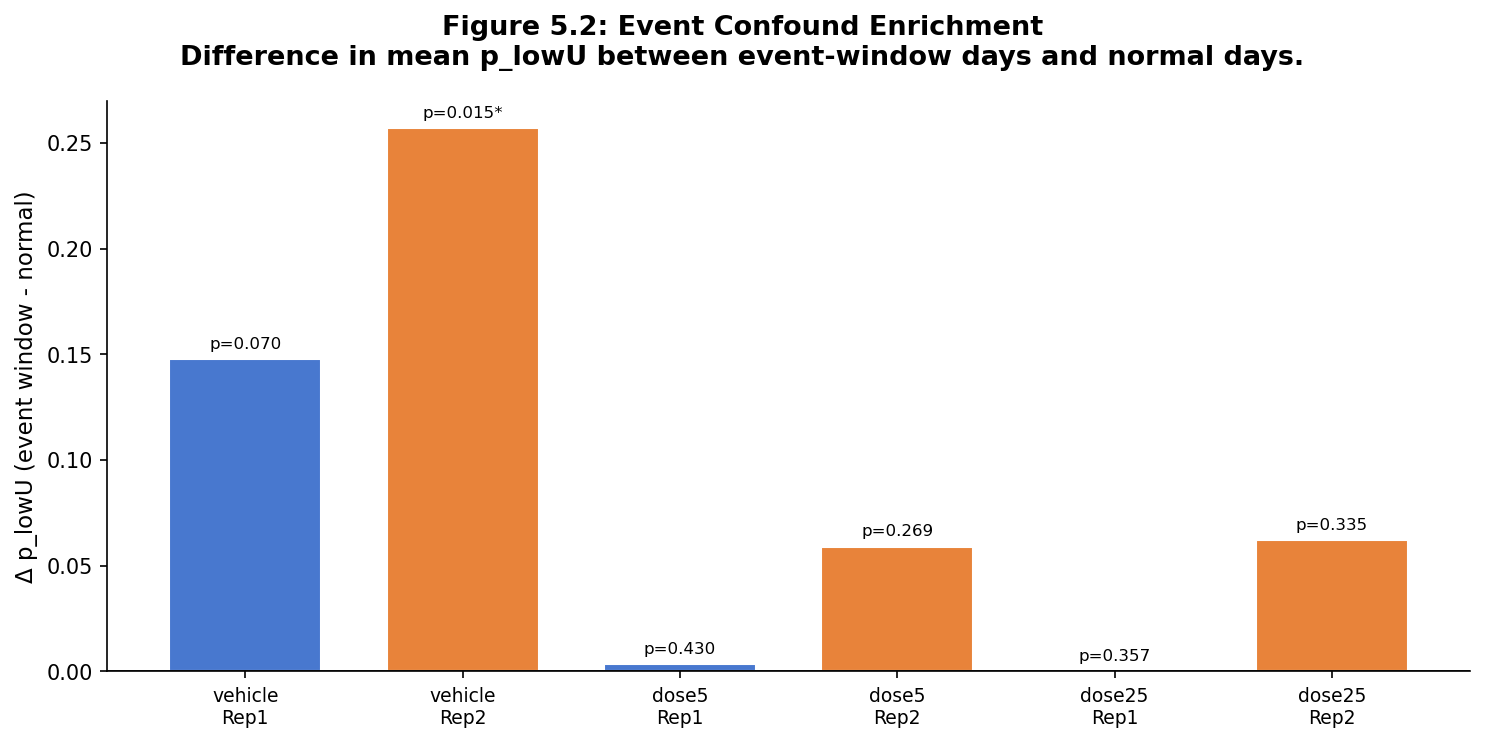

In [21]:
# =============================================================================
# Figure 5.2: Event Confound Enrichment
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure 5.2: Event Confound Enrichment\n"
             "Difference in mean p_lowU between event-window days and normal days.",
             fontsize=13, fontweight="bold")

x_labels = []
deltas = []
mwu_ps = []
colors = []

for g in ["vehicle", "dose5", "dose25"]:
    for r in ["Rep1", "Rep2"]:
        row = confound_df[(confound_df["group"] == g) & (confound_df["replicate"] == r)]
        if len(row) > 0:
            x_labels.append(f"{g}\n{r}")
            deltas.append(row.iloc[0]["delta"])
            mwu_ps.append(row.iloc[0]["mwu_p"])
            colors.append(REP_COLORS[r])

bars = ax.bar(range(len(deltas)), deltas, color=colors, edgecolor="white", width=0.7)
for bi, (d, p) in enumerate(zip(deltas, mwu_ps)):
    sig = "*" if pd.notna(p) and p < 0.05 else ""
    ax.text(bi, d + 0.005, f"p={p:.3f}{sig}", ha="center", fontsize=8)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ p_lowU (event window - normal)")
plt.tight_layout()
plt.show()


---
# Act 6: Is There a Dose-Response?


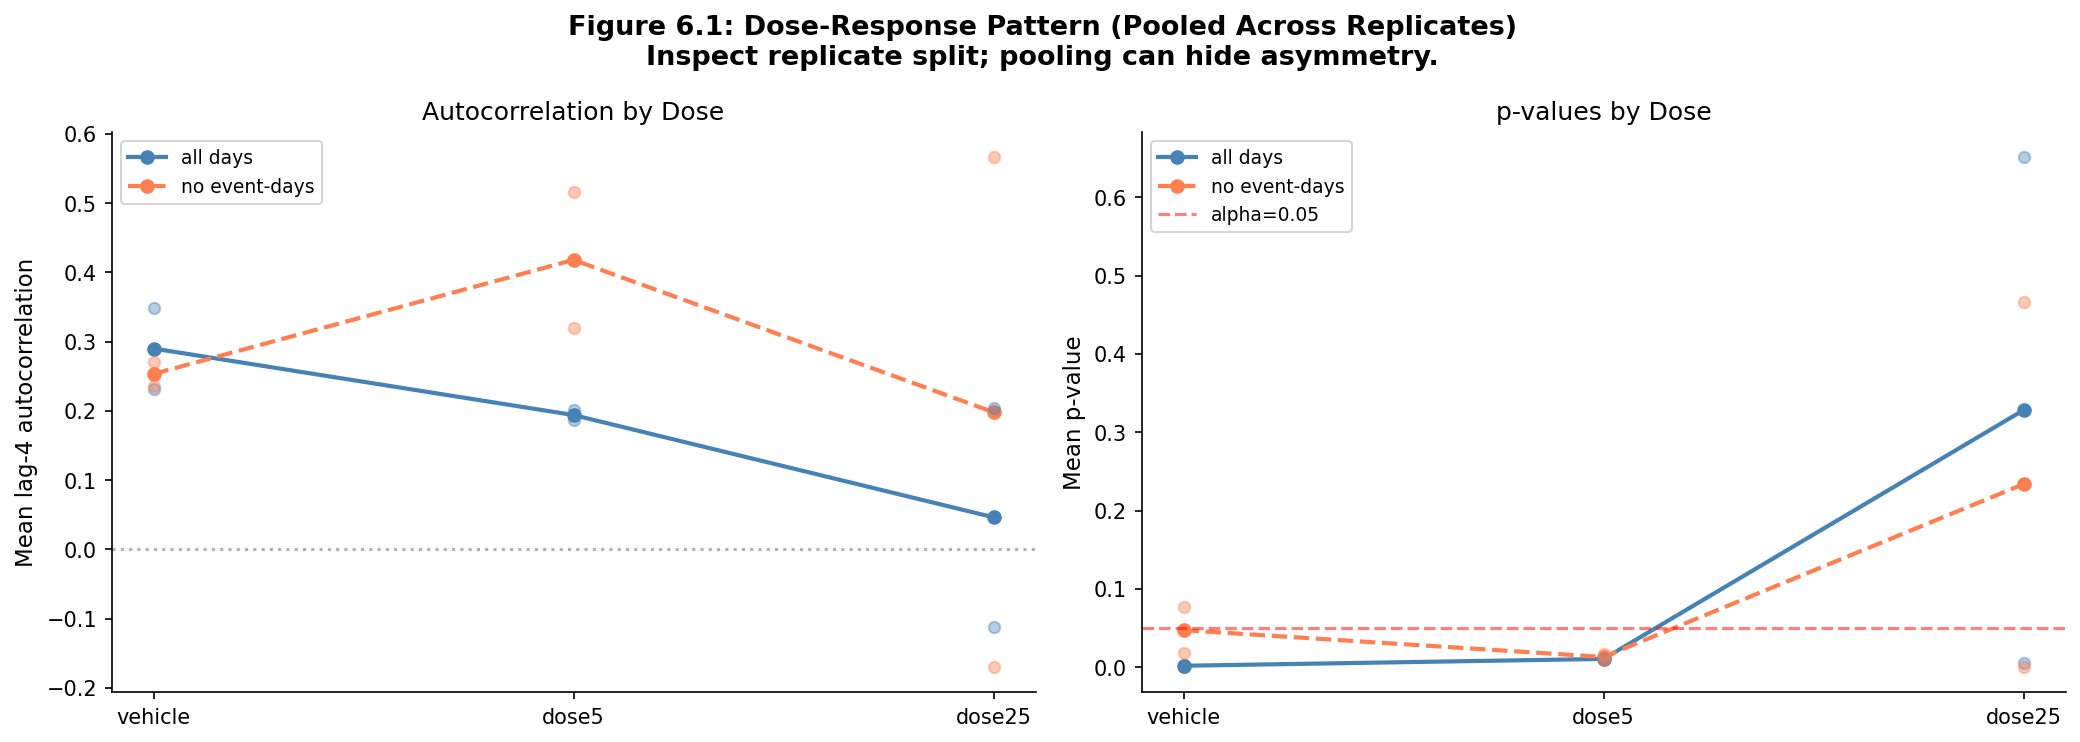

In [22]:
# =============================================================================
# Figure 6.1: Dose-Response Summary
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 6.1: Dose-Response Pattern (Pooled Across Replicates)\n"
             "Inspect replicate split; pooling can hide asymmetry.",
             fontsize=13, fontweight="bold")

groups_ordered = ["vehicle", "dose5", "dose25"]

# Left: Mean autocorrelation by dose
ax = axes[0]
for variant, label, color, ls in [
    ("ac_all", "all days", "steelblue", "-"),
    ("ac_ne", "no event-days", "coral", "--"),
]:
    means = [group_df[group_df["group"] == g][variant].mean() for g in groups_ordered]
    ax.plot(groups_ordered, means, marker="o", label=label, color=color, linewidth=2, linestyle=ls)
    for gi, g in enumerate(groups_ordered):
        rep_vals = group_df[group_df["group"] == g][variant].values
        ax.scatter([gi]*len(rep_vals), rep_vals, color=color, alpha=0.4, s=30, zorder=3)

ax.axhline(0, color="black", linestyle=":", alpha=0.3)
ax.set_ylabel("Mean lag-4 autocorrelation")
ax.set_title("Autocorrelation by Dose")
ax.legend(fontsize=9)

# Right: p-values by dose
ax = axes[1]
for variant, label, color, ls in [
    ("p_all", "all days", "steelblue", "-"),
    ("p_ne", "no event-days", "coral", "--"),
]:
    means = [group_df[group_df["group"] == g][variant].mean() for g in groups_ordered]
    ax.plot(groups_ordered, means, marker="o", label=label, color=color, linewidth=2, linestyle=ls)
    for gi, g in enumerate(groups_ordered):
        rep_vals = group_df[group_df["group"] == g][variant].values
        ax.scatter([gi]*len(rep_vals), rep_vals, color=color, alpha=0.4, s=30, zorder=3)

ax.axhline(0.05, color="red", linestyle="--", alpha=0.5, label="alpha=0.05")
ax.set_ylabel("Mean p-value")
ax.set_title("p-values by Dose")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
# Comprehensive Summary


In [23]:
# =============================================================================
# COMPREHENSIVE SUMMARY
# =============================================================================
print("=" * 120)
print("MORPH2REP ULTRADIAN CYCLICITY REPORT: COMPREHENSIVE SUMMARY")
print("=" * 120)

print(f"""
METHODOLOGY
-----------
Pipeline: Per-mouse GMM + Shuffle permutation + Baseline-anchored z-scoring + per-mouse clipping
Signal: Locomotion bout overlap counts (1-min) from animal_bouts.parquet
Wavelet: CWT Morlet, 1-3h ultradian band power (daily mean, scale-wise max)
Z-scoring: Baseline-anchored (median/MAD from pre-dose days only)
Clipping: Per-mouse |z| quantile (Q_CLIP) computed on baseline days; applied to all days
GMM: Per-mouse, 2-component 1D on z_U_1_3h -> p_lowU  (fit on all QC-kept days)
Individual test: Shuffle permutation ({N_SIMS_IND} sims) + parametric z-test, lag={LAG}
Group test: Shuffle permutation ({N_SIMS_GRP} sims) on pooled mean autocorrelation, lag={LAG}
Event handling: No minute-level exclusion. Day-level censoring as sensitivity only.
""")

print("=" * 120)
print("1. QC SUMMARY")
print("=" * 120)
qc_summary = feat.groupby(["group", "replicate"]).agg(
    total_rows=("animal_id", "size"), kept_rows=("qc_keep", "sum"),
    keep_rate=("qc_keep", "mean"), n_animals=("animal_id", "nunique"),
).reset_index()
print(qc_summary.round(3).to_string(index=False))
print(f"\nThresholds: minutes >= {THR_MINUTES}, ratio >= {THR_RATIO}, min days/mouse >= {MIN_QC_DAYS}")

print("\n" + "=" * 120)
print("2. PER-MOUSE GMM SUMMARY")
print("=" * 120)
gmm_ok = gmm_df[gmm_df["status"] == "ok"]
print(f"Total mice: {len(gmm_df)}, Succeeded: {n_ok}")
if n_ok > 0:
    print(f"Mean component separation: {gmm_ok['sep'].mean():.3f} (std={gmm_ok['sep'].std():.3f})")
    print(f"p_lowU >0.9: {(feat_qc['p_lowU'] > 0.9).mean():.3f}, <0.1: {(feat_qc['p_lowU'] < 0.1).mean():.3f}")

print("\n" + "=" * 120)
print("3. INDIVIDUAL-LEVEL CYCLICITY")
print("=" * 120)
print(f"Total mice: {len(indiv_df)}, Expected FP at alpha=0.05: {expected_fp:.1f}")
print(f"Significant (shuffle): {n_sig}, Significant (parametric): {(indiv_df['p_param_all'] < 0.05).sum()}")

print("\nBy group:")
for g in ["vehicle", "dose5", "dose25"]:
    s = indiv_df[indiv_df["group"] == g]
    print(f"  {g}: {(s['p_shuffle_all']<0.05).sum()}/{len(s)} sig, mean_ac={s['autocorr_all'].mean():.4f}")

print("\nBy replicate:")
for r in ["Rep1", "Rep2"]:
    s = indiv_df[indiv_df["replicate"] == r]
    print(f"  {r}: {(s['p_shuffle_all']<0.05).sum()}/{len(s)} sig, mean_ac={s['autocorr_all'].mean():.4f}")

print("\nTop 10 mice:")
top10 = indiv_df.nsmallest(10, "p_shuffle_all")[["group","replicate","animal_id","n_days",
    "autocorr_all","p_shuffle_all","p_param_all","autocorr_ne","p_shuffle_ne"]]
print(top10.round(4).to_string(index=False))

print("\n" + "=" * 120)
print("4. GROUP-LEVEL CYCLICITY")
print("=" * 120)
print(group_df[["group","replicate","n_mice","ac_all","p_all","ac_ne","p_ne","ac_nw","p_nw"]].round(4).to_string(index=False))

print("\n" + "=" * 120)
print("5. REP1 vs REP2 SIGN FLIP")
print("=" * 120)
for g in ["vehicle", "dose5", "dose25"]:
    r1 = group_df[(group_df["group"]==g)&(group_df["replicate"]=="Rep1")]
    r2 = group_df[(group_df["group"]==g)&(group_df["replicate"]=="Rep2")]
    if len(r1)>0 and len(r2)>0:
        a1, a2 = r1["ac_all"].values[0], r2["ac_all"].values[0]
        sign = "SAME" if (a1>0)==(a2>0) else "OPPOSITE"
        print(f"  {g}: Rep1={a1:+.4f}, Rep2={a2:+.4f} -> {sign}")

print("\n" + "=" * 120)
print("6. EVENT CONFOUND ENRICHMENT")
print("=" * 120)
print(confound_df.round(4).to_string(index=False))

print("\n" + "=" * 120)
print("7. EVENT SENSITIVITY")
print("=" * 120)
for _, row in group_df.iterrows():
    ac_all, ac_ne = row["ac_all"], row["ac_ne"]
    drop = ac_all - ac_ne if pd.notna(ac_all) and pd.notna(ac_ne) else np.nan
    print(f"  {row['group']:7s} {row['replicate']}: all={ac_all:+.4f} -> censored={ac_ne:+.4f} (change={drop:+.4f})")

print("\n" + "=" * 120)
print("8. DOSE-RESPONSE (pooled across replicates)")
print("=" * 120)
for g in ["vehicle", "dose5", "dose25"]:
    s = group_df[group_df["group"]==g]
    c = confound_df[confound_df["group"]==g]
    print(f"  {g}: ac_all={s['ac_all'].mean():+.4f} (p={s['p_all'].mean():.4f}), "
          f"ac_ne={s['ac_ne'].mean():+.4f} (p={s['p_ne'].mean():.4f}), "
          f"event_delta={c['delta'].mean():+.4f}")

print("\n" + "=" * 120)
print("END OF REPORT")
print("=" * 120)


MORPH2REP ULTRADIAN CYCLICITY REPORT: COMPREHENSIVE SUMMARY

METHODOLOGY
-----------
Pipeline: Per-mouse GMM + Shuffle permutation + Baseline-anchored z-scoring + per-mouse clipping
Signal: Locomotion bout overlap counts (1-min) from animal_bouts.parquet
Wavelet: CWT Morlet, 1-3h ultradian band power (daily mean, scale-wise max)
Z-scoring: Baseline-anchored (median/MAD from pre-dose days only)
Clipping: Per-mouse |z| quantile (Q_CLIP) computed on baseline days; applied to all days
GMM: Per-mouse, 2-component 1D on z_U_1_3h -> p_lowU  (fit on all QC-kept days)
Individual test: Shuffle permutation (5000 sims) + parametric z-test, lag=4
Group test: Shuffle permutation (2000 sims) on pooled mean autocorrelation, lag=4
Event handling: No minute-level exclusion. Day-level censoring as sensitivity only.

1. QC SUMMARY
  group replicate  total_rows  kept_rows  keep_rate  n_animals
 dose25      Rep1         135        135      1.000          9
 dose25      Rep2         117        117      1.000

In [24]:
# =============================================================================
# Export CSV requested: mouse id, cage id, date, and p_lowU
# =============================================================================
out_cols = ["animal_id", "cage_id", "date", "group", "replicate", "day", "p_lowU"]
p_lowU_table = feat_qc[out_cols].sort_values(["group","replicate","cage_id","animal_id","day"]).reset_index(drop=True)

csv_path = "p_lowU_clipped_table.csv"
p_lowU_table.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}  | rows={len(p_lowU_table)}")


Saved: p_lowU_clipped_table.csv  | rows=747
